# 2022~2023 채용 플랫폼 지원 활성화 분석

이 노트북은 **플랫폼 전체 현황 → SW 개발 직무 선정 → 기업·공고 특성 → 북마크 → 북마크 이후 행동** 순서로 분석한다. 전처리 기준과 분석 코드를 한 파일에 포함해 다른 분석자가 동일한 결과를 다시 확인할 수 있도록 구성한다.

| 항목 | 정의 |
|---|---|
| 분석 목적 | SW 개발 공고의 지원 성과와 함께 나타나는 기업·공고·사용자 행동 요인 탐색 |
| 분석 기간 | 2022-01-01 00:00:00 이상, 2024-01-01 00:00:00 미만(KST) |
| 핵심 KPI | 공고별 분석 기간 내 고유 지원자 수 |
| 주요 분석 단위 | 공고, 사용자–공고 조합, URL 로그 이벤트 |
| 해석 범위 | 관찰자료의 관련성 분석. 인과 효과로 단정하지 않음 |

> **권장 실행 방법:** `런타임 → 세션 다시 시작 및 모두 실행`을 사용한다. 중간 셀부터 실행하면 앞에서 생성한 데이터프레임이 없어 오류가 발생할 수 있다.


## 노트북 한눈에 보기

### 분석 질문

1. 플랫폼의 공고와 지원은 어떤 규모와 분포를 보이는가?
2. 여러 직무 중 SW 개발을 우선 분석하는 근거는 무엇인가?
3. SW 개발 공고의 지원자 수 구간별로 기업·공고 특성은 어떻게 다른가?
4. 북마크와 지원은 어떤 관련성을 보이는가?
5. 북마크 이후 동일 공고 지원 집단과 미지원 집단의 행동은 어떻게 다른가?

### 분석 흐름

`플랫폼 현황 → 직무 비교 → SW 개발 드릴다운 → 기업·공고 특성 → 북마크 지표 → 행동 경로 비교 → 한계와 후속 검증`

### 데이터 단위

| 데이터 | 기본 단위 | 주요 용도 |
|---|---|---|
| 분석용 전처리 데이터 | 공고 1건 | 공고 수, 고유 지원자 수, 기업·공고 특성 |
| Application | 사용자–공고 지원 1건 | 지원자 집합과 지원 시점 확인 |
| JobBookmark | 사용자–공고 북마크 1건 | 북마크 시점과 동일 공고 전환 확인 |
| log | URL 요청 이벤트 1건 | 검색·탐색·관심·지원 준비 행동 관찰 |

### 핵심 해석 원칙

- 원본 컬럼은 보존하고 변환·파생 컬럼을 별도 생성한다.
- 결측치와 이상치는 자동 삭제하지 않고 플래그와 별도 기준으로 관리한다.
- 북마크 수와 지원자 수의 동반 증가는 상관관계이며, 북마크의 인과 효과를 뜻하지 않는다.
- 로그에 공고 ID가 안정적으로 남지 않는 URL은 사용자 행동 수준으로만 해석한다.


# I. 전처리

분석 기간과 시간대를 통일하고, 원본 컬럼을 보존한 상태에서 분석용 파생변수와 품질 점검 지표를 생성한다. 아래 셀은 번호 순서대로 실행한다.


## **0. 환경설정 및 데이터 불러오기**

분석 로직과 분리해 라이브러리, 한글 폰트, Drive 연결, 입력 파일 경로만 설정한다.


### **0.1 라이브러리·한글 폰트 설정**

Colab과 로컬 환경을 구분하고, 모든 차트에서 한글과 숫자가 동일하게 표시되도록 폰트를 설정한다.


In [ ]:
# 1) 기본 라이브러리
from pathlib import Path
import platform
import re
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch

# 2) 실행 환경 확인
# 코랩 실행 여부를 확인
try:
    import google.colab
    is_colab = True
except (ImportError, ModuleNotFoundError):
    is_colab = False

# 3) 한글 폰트 설정
# 코랩에 폰트가 없으면
# 한 번만 설치
if is_colab and not any(
    "NanumGothic" in font.name
    for font in font_manager.fontManager.ttflist
):
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "fonts-nanum"],
        check=True,
        stdout=subprocess.DEVNULL,
    )
    for font_file in Path(
        "/usr/share/fonts/truetype/nanum"
    ).glob("*.ttf"):
        font_manager.fontManager.addfont(str(font_file))

operating_system = platform.system()
if is_colab:
    nanum_file = next(
        Path("/usr/share/fonts/truetype/nanum").glob(
            "NanumGothic*.ttf"
        ),
        None,
    )
    korean_font_name = (
        font_manager.FontProperties(
            fname=str(nanum_file)
        ).get_name()
        if nanum_file
        else "NanumGothic"
    )
elif operating_system == "Windows":
    korean_font_name = "Malgun Gothic"
elif operating_system == "Darwin":
    korean_font_name = "AppleGothic"
else:
    korean_font_name = "NanumGothic"

# 4) 차트 표시 설정
# 한글과 음수 기호가
# 정상적으로 보이도록 적용
plt.rcParams["font.family"] = korean_font_name
plt.rcParams["font.sans-serif"] = [korean_font_name]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=korean_font_name)


### **0.2 Drive 연결 및 입력 파일 준비**

Colab에서는 현재 로그인한 Google 계정으로 팀 공유 파일을 `/content/2022_2023_전처리`에 내려받는다. 이미 파일이 있으면 다시 내려받지 않는다. 로컬에서는 프로젝트의 전처리 결과 폴더를 사용한다.

> 입력 파일 ID는 재현성을 위해 코드에 남겨두며, 접근 권한이 없는 계정에서는 다운로드가 실패한다.


In [ ]:
# 공개 저장소에는 팀 내부 Google Drive 파일 ID를 포함하지 않습니다.
# notebooks/README.md의 입력 목록에 따라 접근 권한이 있는 데이터를 준비하세요.
work_dir = Path.cwd().parent / "data" / "private"
work_dir.mkdir(parents=True, exist_ok=True)
drive_file_specs = []
preprocessed_data_path = work_dir / "분석용_전처리데이터_2022_2023.csv"
quality_report_path = work_dir / "전처리_품질점검표_2022_2023.csv"
full_period_summary_path = work_dir / "전체기간_직무별_지원현황_요약.csv"
raw_data_dir = work_dir.parent / "원천데이터"
print(f"입력 폴더: {work_dir}")


## **1. 공통 전처리 기준**

| 기준 | 적용 내용 |
|---|---|
| 분석 기간 | 2022-01-01 이상, 2024-01-01 미만 |
| 시간대 | UTC 원문을 보존하고 KST 파생 시각 생성 |
| 원본 보존 | 원본 컬럼을 덮어쓰지 않고 변환·파생 컬럼 별도 생성 |
| 결측·이상치 | 임의 삭제하지 않고 결측 여부와 이상치 플래그 생성 |
| 지원자 수 | 분석 기간 안에 관측된 고유 지원자 수 사용 |
| 경계값 | 종료일 미만(`< 2024-01-01`) 조건으로 2023-12-31 23:59:59까지 포함 |


In [ ]:
# 분석 기간
# 2022-01-01 ~ 2023-12-31
analysis_start_date = pd.Timestamp("2022-01-01")
analysis_end_date_exclusive = pd.Timestamp("2024-01-01")

# 투자금액 통화 통일 기준
# 환율 기준: 1달러 = 1,200원
usd_krw_rate = 1200


## **2. Application 테이블 전처리**

- **입력:** 지원 시각 `cdate`, 사용자·공고 식별자, 지원자 수 관련 컬럼
- **처리:** UTC 지원 시각을 KST로 변환하고 분석 기간 적용
- **출력:** `application_cdate_kst`, `observed_applicant_count_period`, `applicant_group`, `is_zero_applicant`
- **집계 원칙:** 동일 사용자의 동일 공고 중복 지원은 공고별 고유 지원자 수 계산에서 1명으로 집계


In [ ]:
def preprocess_application_table(data: pd.DataFrame) -> pd.DataFrame:
    """Application 테이블의 지원 시각과 지원자 수 관련 컬럼을 정리한다."""
    result = data.copy()

    # 원본 cdate는 보존하고, 원본 행이 있으면 KST 시각 컬럼을 별도로 생성한다.
    if "cdate" in result.columns:
        result["application_cdate_kst"] = (
            pd.to_datetime(result["cdate"], errors="coerce", utc=True)
            .dt.tz_convert("Asia/Seoul")
        )
        in_period = result["application_cdate_kst"].between(
            analysis_start_date.tz_localize("Asia/Seoul"),
            analysis_end_date_exclusive.tz_localize("Asia/Seoul"),
            inclusive="left",
        )
        result = result.loc[in_period | result["application_cdate_kst"].isna()].copy()

    count_columns = [
        "observed_applicant_count_period",
        "applicant_count_period",
        "application_row_count_period",
    ]
    for column in count_columns:
        if column in result.columns:
            result[column] = pd.to_numeric(
                result[column], errors="coerce"
            ).fillna(0)

    if "observed_applicant_count_period" not in result.columns:
        source_column = next(
            (
                column
                for column in ["applicant_count_period", "applicant_count"]
                if column in result.columns
            ),
            None,
        )
        if source_column:
            result["observed_applicant_count_period"] = pd.to_numeric(
                result[source_column], errors="coerce"
            ).fillna(0)

    if "observed_applicant_count_period" in result.columns:
        result["applicant_group"] = pd.cut(
            result["observed_applicant_count_period"],
            bins=[-1, 0, 1, 3, 10, float("inf")],
            labels=["0명", "1명", "2–3명", "4–10명", "11명 이상"],
        )
        result["is_zero_applicant"] = result[
            "observed_applicant_count_period"
        ].eq(0)
    return result


## **3. Job 테이블 전처리**

- **입력:** 공고 등록일, 시작일, 종료일, 경력 조건
- **처리:** `start_date` 결측은 공고 등록일로 대체하고 `end_date` 결측과 분석 종료일 이후 값은 유지
- **품질 관리:** `start_date > end_date`는 비정상 날짜로 제외하고 게시 기간·경력 형태 파생변수 생성
- **출력:** 날짜 파싱·결측 플래그, 유효 게시 기간, 경력 형태 0/1 변수


In [ ]:
def preprocess_job_table(data: pd.DataFrame) -> pd.DataFrame:
    """합의된 공고 날짜와 경력 조건 전처리 기준을 적용한다."""
    result = data.copy()

    for column in ["job_cdate", "cdate", "start_date", "end_date"]:
        if column in result.columns:
            result[f"{column}_parsed"] = pd.to_datetime(
                result[column], errors="coerce"
            )

    if "job_cdate_parsed" not in result.columns and "cdate_parsed" in result.columns:
        result["job_cdate_parsed"] = result["cdate_parsed"]

    if "job_cdate_parsed" in result.columns:
        in_period = result["job_cdate_parsed"].between(
            analysis_start_date,
            analysis_end_date_exclusive,
            inclusive="left",
        )
        result = result.loc[in_period].copy()

    if "start_date" in result.columns:
        result["start_date_raw"] = result["start_date"].astype("string")
    if "end_date" in result.columns:
        result["end_date_raw"] = result["end_date"].astype("string")

    if "start_date_parsed" in result.columns:
        result["start_date_missing"] = result["start_date_parsed"].isna()
        result["start_date_used"] = result["start_date_parsed"].fillna(
            result["job_cdate_parsed"]
        )

    if "end_date_parsed" in result.columns:
        result["end_date_missing"] = result["end_date_parsed"].isna()
        end_year = pd.to_numeric(
            result["end_date_raw"].str.extract(r"^(\d{4})", expand=False),
            errors="coerce",
        )
        result["is_open_ended_end_date"] = end_year.ge(2100).fillna(False)
        result["end_date_after_period"] = result["end_date_parsed"].ge(
            analysis_end_date_exclusive
        )

    if {"start_date_used", "end_date_parsed"} <= set(result.columns):
        result["start_date_after_end_date"] = (
            result["start_date_used"] > result["end_date_parsed"]
        )
        result = result.loc[
            ~result["start_date_after_end_date"].fillna(False)
        ].copy()
        result["posting_duration_days"] = (
            result["end_date_parsed"] - result["start_date_used"]
        ).dt.days
        result["posting_duration_valid"] = result[
            "posting_duration_days"
        ].between(0, 365)

    if "career_type_string" in result.columns:
        career = (
            result["career_type_string"]
            .astype("string")
            .fillna("")
            .str.replace(r"\s+", "", regex=True)
            .str.lower()
        )
        result["is_career_unrestricted"] = career.str.contains(
            "제한없음|경력무관|무관|any",
            regex=True,
            na=False,
        )
        result["is_intern"] = career.str.contains(
            "인턴|intern", regex=True, na=False
        )
        result["is_entry_level"] = career.str.contains(
            "신입|entry|new", regex=True, na=False
        )
        result["is_experienced"] = career.str.contains(
            "경력|experienced", regex=True, na=False
        ) & ~result["is_career_unrestricted"]
        result["is_career_unknown"] = career.eq("")
    return result


## **4. Company 테이블 전처리**

- **입력:** 직원 수, 조회 수, 팔로우 수, 추천 수
- **처리:** 원본값을 보존하고 비교 가능한 숫자형 파생 컬럼 생성
- **주의:** `employee_count = 0`은 무인 기업으로 단정하지 않고 미입력·비공개 가능성을 포함한 품질 플래그로 해석


In [ ]:
def preprocess_company_table(data: pd.DataFrame) -> pd.DataFrame:
    """Company 테이블의 규모와 기업 행동 지표를 정리한다."""
    result = data.copy()
    # employee_count 원본값은 보존하고, 숫자 비교용 파생 컬럼을 별도로 생성
    if "employee_count" in result.columns:
        result["employee_count_numeric"] = pd.to_numeric(
            result["employee_count"].astype("string").str.extract(r"(\d+)")[0], errors="coerce"
        )
    for column in ["view_count", "follow_count", "reference_count"]:
        if column in result.columns:
            result[column] = pd.to_numeric(result[column], errors="coerce").fillna(0)
    return result


## **5. Companyfund 테이블 전처리**

- **입력:** 투자 금액 `raised`, 통화 `currency`
- **처리:** 금액을 숫자형으로 변환하고 팀 합의 환율 `1 USD = 1,200 KRW`를 적용
- **출력:** 원화 환산 금액과 투자정보 공개 상태
- **주의:** 고정 환율은 비교 편의를 위한 분석 가정이며 실제 투자 시점 환율을 반영하지 않음


In [ ]:
def preprocess_companyfund_table(data: pd.DataFrame) -> pd.DataFrame:
    """투자금액을 원화로 환산하고 투자 상태 분류 기준을 적용한다."""
    result = data.copy()
    raised = None
    if "raised" in result.columns:
        raised = pd.to_numeric(
            result["raised"].astype("string").str.replace(",", "", regex=False),
            errors="coerce",
        )
        currency = result.get(
            "currency", pd.Series("", index=result.index, dtype="string")
        ).fillna("").astype("string").str.upper()
        result["raised_krw"] = raised.where(
            currency.ne("USD"), raised * usd_krw_rate
        )

    record_count = pd.to_numeric(
        result.get(
            "fund_record_count_to_2023",
            pd.Series(0, index=result.index),
        ),
        errors="coerce",
    ).fillna(0)
    positive_amount = (
        raised.gt(0)
        if raised is not None
        else pd.to_numeric(
            result.get(
                "has_positive_raised_to_2023",
                pd.Series(0, index=result.index),
            ),
            errors="coerce",
        ).fillna(0).astype(bool)
    )

    result["funding_status"] = "데이터상 투자 이력 없음"
    result.loc[record_count.gt(0), "funding_status"] = "투자 금액 비공개"
    result.loc[positive_amount, "funding_status"] = "투자 금액 공개"
    return result


## **6. JobBookmark 테이블 전처리**

- **입력:** 사용자·공고 식별자와 북마크 시각 `cdate`
- **처리:** UTC 북마크 시각을 KST로 변환하고 분석 기간 적용
- **출력:** 분석 기간 내 사용자–공고 북마크 이벤트와 공고별 북마크 수


In [ ]:
def preprocess_jobbookmark_table(data: pd.DataFrame) -> pd.DataFrame:
    """북마크 시각을 표준화하거나 이미 집계된 북마크 수를 정리한다."""
    result = data.copy()
    if "cdate" in result.columns:
        result["bookmark_cdate_kst"] = (
            pd.to_datetime(result["cdate"], errors="coerce", utc=True)
            .dt.tz_convert("Asia/Seoul")
        )
        in_period = result["bookmark_cdate_kst"].between(
            analysis_start_date.tz_localize("Asia/Seoul"),
            analysis_end_date_exclusive.tz_localize("Asia/Seoul"),
            inclusive="left",
        )
        result = result.loc[in_period | result["bookmark_cdate_kst"].isna()].copy()
    if "bookmark_count_period" in result.columns:
        result["bookmark_count_period"] = pd.to_numeric(
            result["bookmark_count_period"], errors="coerce"
        ).fillna(0)
    return result


## **7. log 테이블 전처리**

- **입력:** `user_uuid`, `timestamp`, `path/url`, `response_code`, `method`
- **처리:** KST 시각, 분석 기간, 2xx 성공 여부, URL 경로와 행동 유형 생성
- **중복:** 완전 중복 로그는 삭제하지 않고 `is_exact_duplicate_log` 플래그로 관리
- **해석:** 공고 ID가 확인되지 않는 URL은 특정 공고가 아닌 사용자 행동 수준으로만 사용


In [ ]:
def preprocess_log_table(data: pd.DataFrame) -> pd.DataFrame:
    """로그 원본을 KST 기준 분석용 컬럼과 행동 유형으로 변환한다."""
    result = data.copy()

    # 식별자·URL·HTTP 메서드는 문자열로 통일한다.
    for column in ["user_uuid", "URL", "url", "method"]:
        if column in result.columns:
            result[column] = result[column].astype("string")

    # HTTP 응답 코드는 결측을 허용하는 정수형으로 변환하고 성공 여부를 생성한다.
    if "response_code" in result.columns:
        result["response_code"] = pd.to_numeric(
            result["response_code"], errors="coerce"
        ).astype("Int64")
        result["is_success_2xx"] = result["response_code"].between(200, 299)
    else:
        result["response_code"] = pd.Series(pd.NA, index=result.index, dtype="Int64")
        result["is_success_2xx"] = False

    # timestamp 원본은 UTC로 해석하고 KST 분석용 시각을 별도 생성한다.
    if "timestamp" in result.columns:
        result["timestamp_utc"] = pd.to_datetime(
            result["timestamp"], errors="coerce", utc=True
        )
        result["event_time_kst"] = result["timestamp_utc"].dt.tz_convert(
            "Asia/Seoul"
        )
    elif "event_time_kst" in result.columns:
        result["event_time_kst"] = pd.to_datetime(
            result["event_time_kst"], errors="coerce", utc=True
        ).dt.tz_convert("Asia/Seoul")
    else:
        result["timestamp_utc"] = pd.NaT
        result["event_time_kst"] = pd.NaT

    # 분석 기간은 KST 기준 [2022-01-01, 2024-01-01)으로 적용한다.
    analysis_start_kst = analysis_start_date.tz_localize("Asia/Seoul")
    analysis_end_kst = analysis_end_date_exclusive.tz_localize("Asia/Seoul")
    result["is_in_analysis_period"] = result["event_time_kst"].between(
        analysis_start_kst, analysis_end_kst, inclusive="left"
    ).fillna(False)

    # URL 원문은 보존하고, 경로와 쿼리 문자열을 분리한다.
    url_column = "URL" if "URL" in result.columns else "url"
    if url_column in result.columns:
        result["url"] = result[url_column].astype("string")
    else:
        result["url"] = pd.Series(pd.NA, index=result.index, dtype="string")
    url_text = result["url"].fillna("").astype("string")
    result["url_path"] = url_text.str.split("?", n=1).str[0]

    # 실제 공고 UUID로 확인되지 않는 id_title·apply 등은 공고 ID로 저장하지 않는다.
    candidate_job_id = result["url_path"].str.extract(
        r"(?:^|/)jobs/id/([^/?]+)$", expand=False
    ).astype("string")
    placeholder_job_id = candidate_job_id.str.lower().isin(
        ["id", "id_title", "null", "apply", "bookmarks", "applications", "edit"]
    )
    result["job_uuid_from_url"] = candidate_job_id.where(
        candidate_job_id.notna() & ~placeholder_job_id
    ).astype("string")

    # 현재 분석 방향에 맞춰 URL을 행동 유형으로 분류한다.
    result["event_type"] = "기타"
    event_rules = [
        (r"recommend", "추천"),
        (r"following|follow", "관심 직무·기업"),
        (r"bookmark", "북마크"),
        (r"resume|template|career|language|profile", "프로필 관리"),
        (r"reference", "레퍼런스"),
        (r"apply", "지원 흐름"),
    ]
    for pattern, event_name in event_rules:
        mask = result["event_type"].eq("기타") & url_text.str.contains(
            pattern, case=False, regex=True, na=False
        )
        result.loc[mask, "event_type"] = event_name

    # jobs/id/ 경로는 공고 상세·지원 흐름이므로 검색으로 분류하지 않는다.
    # 실제 채용 검색 경로와 검색 API만 검색 행동으로 분류한다.
    search_path_mask = (
        result["event_type"].eq("기타")
        & ~result["url_path"].str.contains(r"jobs/id/", case=False, regex=True, na=False)
        & result["url_path"].str.contains(
            r"(?:^|/)jobs(?:\?|$)|api/jobs/job_title|api/search/|(?:^|/)search(?:\?|$)|(?:^|/)suggest(?:\?|$)",
            case=False, regex=True, na=False,
        )
    )
    result.loc[search_path_mask, "event_type"] = "검색"

    # 원본 컬럼 전체 값이 같은 행은 중복 플래그만 생성하고 자동 삭제하지 않는다.
    result["is_exact_duplicate_log"] = result.duplicated(keep=False)
    return result


## **8. 테이블별 전처리 함수 통합**

앞에서 정의한 테이블별 전처리 함수를 분석용 통합 데이터에 순서대로 적용한다.


In [ ]:
def preprocess_all_tables(data: pd.DataFrame) -> pd.DataFrame:
    """테이블별 전처리 함수를 정의된 순서로 적용한다."""
    result = preprocess_job_table(data)
    result = preprocess_application_table(result)
    result = preprocess_company_table(result)
    result = preprocess_companyfund_table(result)
    result = preprocess_jobbookmark_table(result)
    return result


## **9. 분석용 파생변수·이상치 기준**

이상치는 오류로 단정하지 않고 **검토 후보**로 표시한다.

- `IQR = Q3 - Q1`
- 상한선: `Q3 + 1.5 × IQR`
- 상한선 초과 값에 `True` 플래그 생성
- 지원자 수 이상치는 전체 공고의 관측 지원자 수로 계산
- 게시 기간 이상치는 `posting_duration_valid=True`인 유효 기간만 사용


In [ ]:
# 이상치 선별 함수를 정의한다. 실제 데이터 적용은 10번 전처리 실행에서 수행한다.
def add_iqr_outlier_flags(data):
    result = data.copy()
    threshold_rows = []

    def apply_upper_iqr(series, metric_name):
        numeric = pd.to_numeric(series, errors="coerce")
        q1 = numeric.quantile(0.25)
        q3 = numeric.quantile(0.75)
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        flag = numeric.gt(upper).fillna(False)
        threshold_rows.append({
            "항목": metric_name,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "상한선(Q3+1.5×IQR)": upper,
            "이상치 후보 수": int(flag.sum()),
        })
        return flag

    if "observed_applicant_count_period" in result.columns:
        result["applicant_count_iqr_outlier"] = apply_upper_iqr(
            result["observed_applicant_count_period"], "관측 지원자 수"
        )

    if "posting_duration_days" in result.columns:
        duration = pd.to_numeric(result["posting_duration_days"], errors="coerce")
        if "posting_duration_valid" in result.columns:
            duration = duration.where(result["posting_duration_valid"].fillna(False))
        result["posting_duration_iqr_outlier"] = apply_upper_iqr(
            duration, "유효 게시기간(일)"
        )

    return result, pd.DataFrame(threshold_rows)


## **10. 전처리 실행**

원천 CSV가 있으면 위 함수를 직접 적용한다. 원천 데이터가 없으면 팀 공유 전처리 완료 CSV를 불러온 뒤 동일한 이상치 플래그를 생성한다.


In [ ]:
# 원천 CSV가 있으면 위 함수를 직접 실행하고,
# 없으면 팀 드라이브에 공유된 전처리 완료 데이터를 사용
raw_candidates = list(raw_data_dir.glob("*.csv")) if raw_data_dir.exists() else []

if raw_candidates:
    raw_path = next(
        (path for path in raw_candidates if "job" in path.stem.lower() or "공고" in path.stem),
        raw_candidates[0],
    )
    analysis_data = preprocess_all_tables(pd.read_csv(raw_path, encoding="utf-8-sig"))
    data_source_description = f"원천 CSV 직접 전처리: {raw_path.name}"
else:
    analysis_data = pd.read_csv(preprocessed_data_path, encoding="utf-8-sig")
    quality_report = pd.read_csv(quality_report_path, encoding="utf-8-sig")
    data_source_description = "팀 공유 전처리 완료 CSV 사용"

print("데이터 사용 방식:", data_source_description)
print(f"분석 대상 공고 수: {len(analysis_data):,}건")
display(analysis_data.head(3))
# 전처리된 데이터에 이상치 플래그를 적용하고 실제 기준값을 확인한다.
analysis_data, iqr_thresholds = add_iqr_outlier_flags(analysis_data)
display(iqr_thresholds.style.format({
    "Q1": "{:,.2f}",
    "Q3": "{:,.2f}",
    "IQR": "{:,.2f}",
    "상한선(Q3+1.5×IQR)": "{:,.2f}",
    "이상치 후보 수": "{:,}",
}))


## **11. 전처리 품질 점검**

행 수·고유 공고 수·지원자 수 결측·날짜 결측·유효 게시 기간 비율을 확인한다. 품질 점검값은 삭제 기준이 아니라 분석 범위와 한계를 설명하는 근거로 사용한다.


In [ ]:
# 기존 품질점검표와 핵심 지표를 함께 확인
if "quality_report" in globals():
    display(quality_report)

quality_checks = [("전체 행 수", len(analysis_data))]
if "job_uuid" in analysis_data:
    quality_checks.append(("고유 공고 수", analysis_data["job_uuid"].nunique()))
if "observed_applicant_count_period" in analysis_data:
    quality_checks.append(
        (
            "지원자 수 결측 건수",
            int(analysis_data["observed_applicant_count_period"].isna().sum()),
        )
    )
if "start_date_missing" in analysis_data:
    quality_checks.append(
        ("start_date 원본 결측률", f"{analysis_data['start_date_missing'].mean():.1%}")
    )
if "posting_duration_valid" in analysis_data:
    quality_checks.append(
        ("유효 게시 기간 비율", f"{analysis_data['posting_duration_valid'].mean():.1%}")
    )

display(pd.DataFrame(quality_checks, columns=["점검 항목", "결과"]))

### **11.1. 공고 분석 데이터 전처리 결과**

분석 기간 공고가 전처리 과정에서 어떻게 처리되었는지 확인한다. 날짜 결측과 IQR 이상치는 원칙에 따라 보존하고, 날짜 순서가 역전된 공고만 유효 기간 분석에서 제외한다.


In [ ]:
# 품질 점검표에서 전처리 건수를 불러와 처리 결과 요약표 생성
quality_value_map = {}
if "quality_report" in globals() and not quality_report.empty:
    quality_key_column = next(
        (column for column in ["check", "점검 항목", "항목"] if column in quality_report.columns),
        None,
    )
    quality_value_column = next(
        (column for column in ["value", "결과", "건수"] if column in quality_report.columns),
        None,
    )
    if quality_key_column and quality_value_column:
        quality_value_map = dict(
            zip(quality_report[quality_key_column], quality_report[quality_value_column])
        )

def get_quality_count(key, default=0):
    # 문자열·실수로 저장된 품질 점검값을 정수 건수로 통일
    value = quality_value_map.get(key, default)
    try:
        return int(float(str(value).replace(",", "")))
    except (TypeError, ValueError):
        return int(default)

final_job_count = int(len(analysis_data))
chronology_excluded_count = get_quality_count(
    "start_date_after_end_date_excluded_rows",
    0,
)
period_job_count_before_exclusion = final_job_count + chronology_excluded_count

job_preprocess_result = pd.DataFrame(
    [
        (
            "분석 기간 공고",
            period_job_count_before_exclusion,
            "2022-01-01 이상, 2024-01-01 미만 기준 적용",
            chronology_excluded_count,
            final_job_count,
        ),
        (
            "start_date 원본 결측",
            get_quality_count("start_date_missing_rows"),
            "cdate로 대체하고 대체 여부 플래그 생성",
            0,
            get_quality_count("start_date_missing_rows"),
        ),
        (
            "end_date 결측",
            get_quality_count("end_date_missing_rows"),
            "NULL로 유지하고 분석에 포함",
            0,
            get_quality_count("end_date_missing_rows"),
        ),
        (
            "분석 종료일 이후 end_date",
            get_quality_count("end_date_after_period_rows"),
            "삭제하지 않고 분석에 포함",
            0,
            get_quality_count("end_date_after_period_rows"),
        ),
        (
            "지원자 수 IQR 상한 초과",
            get_quality_count("applicant_iqr_outlier_rows"),
            "이상치 플래그만 생성하고 보존",
            0,
            get_quality_count("applicant_iqr_outlier_rows"),
        ),
        (
            "게시 기간 IQR 상한 초과",
            get_quality_count("posting_duration_iqr_outlier_rows"),
            "이상치 플래그만 생성하고 보존",
            0,
            get_quality_count("posting_duration_iqr_outlier_rows"),
        ),
    ],
    columns=["점검 대상", "점검 건수", "처리 방식", "제외 건수", "최종 반영 건수"],
)

display(
    job_preprocess_result.style.format(
        {"점검 건수": "{:,}", "제외 건수": "{:,}", "최종 반영 건수": "{:,}"}
    )
)
print(f"\n공고 데이터 최종 보존율: {final_job_count / period_job_count_before_exclusion:.2%}")


,점검 대상,점검 건수,처리 방식,제외 건수,최종 반영 건수
0,분석 기간 공고,"32,677","2022-01-01 이상, 2024-01-01 미만 기준 적용",14,"32,663"
1,start_date 원본 결측,"11,160",cdate로 대체하고 대체 여부 플래그 생성,0,"11,160"
2,end_date 결측,"4,129",NULL로 유지하고 분석에 포함,0,"4,129"
3,분석 종료일 이후 end_date,659,삭제하지 않고 분석에 포함,0,659
4,지원자 수 IQR 상한 초과,"3,140",이상치 플래그만 생성하고 보존,0,"3,140"
5,게시 기간 IQR 상한 초과,"2,638",이상치 플래그만 생성하고 보존,0,"2,638"



공고 데이터 최종 보존율: 99.96%


## **12. 로그 데이터 전처리 및 SW 지원자 필터링**

로그 원본을 전처리하고, `job`–`application` 연결로 추출한 SW 개발 지원자의 로그만 별도 생성한다.

### **12.1. 로그 전처리 기준**

1. `job.job_field = 'SW 개발'`인 공고 추출
2. 해당 공고의 `job_uuid`와 `application` 조인
3. 전처리 완료 파일 `application_sw_development_2022_2023.csv`를 로그 분석의 기준 지원자 집합으로 사용
4. `user_uuid` 중복 제거
5. `log_2022`, `log_2023`에서 해당 `user_uuid`만 필터링
6. `timestamp`를 UTC에서 KST로 변환
7. 분석 기간을 `2022-01-01 이상, 2024-01-01 미만`으로 필터링
8. URL에서 검색·추천·프로필 관리·북마크 관련 행동 유형 분류

추가 기준: `response_code`가 2xx인 로그를 분석용 성공 이벤트로 사용하고, 그 외 응답은 품질 점검용으로 보존한다. `date` 원본 컬럼은 날짜 기준으로 사용하지 않고 `timestamp`에서 생성한 KST 시각을 기준으로 한다.


### **12.2. SW 개발 지원자 집합 생성**

로그 분석의 SW 개발 지원자 집합은 전처리 완료 파일 `application_sw_development_2022_2023.csv`를 기준으로 생성한다.

이 파일은 분석 기간 내 SW 개발 직무 공고에 지원한 `user_uuid + job_uuid` 매핑이며, 이 매핑에서 중복 `user_uuid`를 제거하여 로그 분석 대상인 **SW 개발 고유 지원자 6,485명**을 생성한다.

공고 등록일 기준 분석 코호트와 지원 시점 기준 로그 분석 코호트는 범위가 다를 수 있으므로, 로그 분석에서는 공고 등록일로 지원자를 다시 제외하지 않는다.

In [ ]:
# 분석 기간 내 SW 개발 공고 지원자를 로그 분석 대상 집합으로 생성한다.
# 공고 등록일 코호트가 아닌 지원 시점 기준 전처리 완료 매핑 파일을 기준으로 사용한다.
canonical_application_candidates = [
    work_dir / "application_sw_development_2022_2023.csv",
    *Path.cwd().rglob("application_sw_development_2022_2023.csv"),
]
canonical_application_candidates = list(dict.fromkeys(
    path for path in canonical_application_candidates if path.exists()
))

sw_job_ids = set(
    analysis_data.loc[analysis_data["job_field"].eq("SW 개발"), "job_uuid"]
    .dropna().astype("string")
)

if not canonical_application_candidates:
    raise FileNotFoundError("application_sw_development_2022_2023.csv 파일을 찾지 못함")

sw_applications = pd.read_csv(
    canonical_application_candidates[0], encoding="utf-8-sig", low_memory=False
)
sw_applications["user_uuid"] = sw_applications["user_uuid"].astype("string")
sw_applications["job_uuid"] = sw_applications["job_uuid"].astype("string")
time_source_column = next(
    (column for column in ["application_cdate_kst", "cdate"] if column in sw_applications.columns),
    None,
)
if time_source_column is None:
    raise ValueError("지원 시점 컬럼(application_cdate_kst 또는 cdate)이 없음")

sw_applications["application_cdate_kst"] = pd.to_datetime(
    sw_applications[time_source_column], errors="coerce", utc=True
)
sw_applications = sw_applications.loc[
    sw_applications["application_cdate_kst"].between(
        analysis_start_date.tz_localize("Asia/Seoul"),
        analysis_end_date_exclusive.tz_localize("Asia/Seoul"),
        inclusive="left",
    )
].copy()
sw_applicant_users = sw_applications["user_uuid"].dropna().drop_duplicates()

print(f"공고 등록일 기준 SW 개발 공고 수: {len(sw_job_ids):,}건")
print(f"로그 분석 기준 SW 개발 지원 공고 수: {sw_applications['job_uuid'].nunique():,}건")
print(f"SW 개발 지원 행 수: {len(sw_applications):,}건")
print(f"SW 개발 고유 지원자 수: {len(sw_applicant_users):,}명")

공고 등록일 기준 SW 개발 공고 수: 13,324건
로그 분석 기준 SW 개발 지원 공고 수: 8,923건
SW 개발 지원 행 수: 64,465건
SW 개발 고유 지원자 수: 6,485명


### **12.3. 북마크→지원 퍼널 분석용 매핑 기준**

북마크 이후 행동 경로 분석의 단위는 사용자 전체가 아니라 **사용자 × 개별 SW 개발 공고**다. 즉, A 공고를 북마크한 뒤 **동일한 A 공고**에 지원했는지를 확인한다.

```text
SW 개발 공고
 ├─ JobBookmark: user_uuid + job_uuid + bookmark_cdate
 └─ Application: user_uuid + job_uuid + application_cdate
                    ↓
            user_uuid + job_uuid 기준 조인
                    ↓
 application_time_kst ≥ bookmark_time_kst → 동일 공고 지원 전환
```

#### 적용 기준

| 구분 | 적용 기준 |
|---|---|
| 분석 범위 | SW 개발 공고, 2022-01-01 이상 ~ 2024-01-01 미만(KST) |
| 분석 단위 | `user_uuid + job_uuid` 조합 1건 |
| 북마크 시점 | 같은 사용자·공고에서 가장 이른 북마크 시점 유지 |
| 지원 시점 | 같은 사용자·공고에서 가장 이른 지원 시점 유지 |
| 조인 방식 | 북마크를 기준으로 `Application`을 좌측 조인. 모든 북마크 공고를 분모에 포함 |
| 전환 판정 | 지원 시점이 북마크 시점과 같거나 뒤인 경우만 동일 공고 전환으로 판정 |
| 생성 변수 | `bookmark_time_kst`, `application_time_kst`, `is_applied_after_bookmark`, `days_to_application` |

#### 해석 범위

- A를 북마크하고 B에 지원한 경우는 **A 미지원·다른 공고 지원**으로 분리 가능
- 로그 URL에는 중간 행동의 `job_uuid`가 안정적으로 남지 않아, 북마크 뒤의 검색·추천·프로필 행동이 A 공고에 대한 행동이라고 단정하지 않음


In [ ]:
# 북마크→지원 퍼널 매핑 기준을 표로 확인.
funnel_mapping_criteria = pd.DataFrame(
    [
        ("북마크 원천", "JobBookmark", "user_uuid, job_uuid, bookmark_cdate"),
        ("지원 원천", "Application", "user_uuid, job_uuid, application_cdate"),
        ("시간 표준", "KST", "UTC 원문 시간을 KST로 변환"),
        ("조인 키", "user_uuid + job_uuid", "같은 사용자의 같은 공고만 연결"),
        ("중복 처리", "가장 이른 시점 유지", "사용자-공고 조합당 북마크·지원 각 1건"),
        ("전환 조건", "지원 시점 ≥ 북마크 시점", "북마크 후 동일 공고 지원만 전환으로 판정"),
    ],
    columns=["구분", "적용 내용", "의미"],
)
display(Markdown("#### 북마크 행동 경로 분석에 사용하는 테이블 매핑 요약"))
display(funnel_mapping_criteria)


### **12.4. 로그 불러오기·전처리·지원자 필터링**

원본 로그 또는 기존 로그 정제 파일을 읽고 KST 시간, 성공 응답, URL 행동 유형을 생성한다. 이후 SW 개발 지원자 `user_uuid`에 해당하는 로그만 별도 저장한다.

In [ ]:
# 현재 전처리된 SW 개발 지원자 로그를 우선 사용한다.
# 원본 전체 로그를 다시 읽는 경우에는 아래 후보 경로 중 존재하는 파일을 사용한다.
direct_sw_log_paths = []
log_input_paths = [
    path for path in Path.cwd().rglob("*2022_2023.csv.gz")
    if 20_000_000 <= path.stat().st_size <= 27_000_000
]
existing_log_paths = list(dict.fromkeys(path for path in log_input_paths if path.exists()))

log_frames = []
for log_path in existing_log_paths:
    log_frames.append(pd.read_csv(log_path, compression="infer", low_memory=False))

if log_frames:
    log_data = pd.concat(log_frames, ignore_index=True).drop_duplicates()
    log_data = preprocess_log_table(log_data)
    log_data = log_data.loc[log_data["is_in_analysis_period"]].copy()
    analysis_logs = log_data.loc[log_data["is_success_2xx"]].copy()
    sw_applicant_logs = log_data.loc[log_data["user_uuid"].isin(set(sw_applicant_users))].copy()
    sw_applicant_analysis_logs = analysis_logs.loc[analysis_logs["user_uuid"].isin(set(sw_applicant_users))].copy()
    log_output_dir = work_dir / "로그_전처리_결과"
    log_output_dir.mkdir(parents=True, exist_ok=True)
    sw_applicant_analysis_logs.to_csv(log_output_dir / "SW개발_지원자_로그_2022_2023.csv.gz", index=False, encoding="utf-8-sig", compression="gzip")
    log_event_summary = (
        sw_applicant_analysis_logs.groupby("event_type", dropna=False)
        .agg(로그_수=("user_uuid", "size"), 고유_사용자_수=("user_uuid", "nunique"))
        .sort_values("고유_사용자_수", ascending=False)
    )
    print(f"사용한 로그 파일: {existing_log_paths[0].name}")
    print(f"분석 기간 내 전체 로그 수: {len(log_data):,}건")
    print(f"2xx 성공 로그 수: {len(analysis_logs):,}건")
    print(f"SW 개발 지원자 로그 수: {len(sw_applicant_logs):,}건")
    display(log_event_summary)
else:
    log_data = pd.DataFrame()
    analysis_logs = pd.DataFrame()
    sw_applicant_logs = pd.DataFrame()
    sw_applicant_analysis_logs = pd.DataFrame()
    print("로그 입력 파일이 없어 로그 전처리를 실행하지 않음")
    print("필요 입력: SW개발_지원자_로그_2022_2023.csv.gz 또는 로그 정제 파일")

### **12.5. 로그 전처리 품질 점검**

전체 중복 로그는 자동 삭제하지 않고 플래그로 관리한다. 로그 URL에 실제 `job_uuid`가 없는 경우에는 특정 공고 조회·북마크로 연결하지 않고 사용자 행동 수준으로만 해석한다.

In [ ]:
# 로그 전처리 결과의 핵심 품질 지표를 확인한다.
if not log_data.empty:
    log_quality = pd.DataFrame(
        [
            ("분석 기간 로그 수", len(log_data)),
            ("2xx 성공 로그 수", int(log_data["is_success_2xx"].sum())),
            ("timestamp 변환 결측 수", int(log_data["event_time_kst"].isna().sum())),
            ("user_uuid 결측 수", int(log_data["user_uuid"].isna().sum())),
            ("URL 결측 수", int(log_data["url"].isna().sum())),
            ("완전 중복 로그 플래그 행 수", int(log_data["is_exact_duplicate_log"].sum())),
            ("URL에서 job_uuid 확인 로그 수", int(log_data["job_uuid_from_url"].notna().sum())),
            ("SW 지원자 로그 고유 사용자 수", int(sw_applicant_logs["user_uuid"].nunique())),
        ],
        columns=["점검 항목", "결과"],
    )
    display(log_quality)
else:
    print("로그 품질 점검은 입력 파일 확인 후 실행 가능")

#### **12.5.1. 로그 데이터 처리 결과**

분석 기간 로그에서 성공 응답만 행동 분석에 사용한 결과와 주요 품질 점검 건수를 확인한다. 비성공 응답은 삭제된 오류가 아니라 행동 집계 대상에서 제외된 로그다.


In [ ]:
# 로그 분석 대상의 처리 전·후 건수와 제외 비율 확인
if not log_data.empty:
    period_log_count = int(len(log_data))
    success_log_count = int(log_data["is_success_2xx"].sum())
    non_success_log_count = period_log_count - success_log_count

    log_preprocess_result = pd.DataFrame(
        [
            (
                "분석 기간 로그",
                period_log_count,
                "2022-01-01 이상, 2024-01-01 미만 기준 적용",
                0,
                period_log_count,
            ),
            (
                "비성공 응답 로그",
                non_success_log_count,
                "2xx가 아니므로 행동 분석 대상에서 제외",
                non_success_log_count,
                0,
            ),
            (
                "2xx 성공 로그",
                success_log_count,
                "사용자 행동 분석에 사용",
                0,
                success_log_count,
            ),
            (
                "timestamp 변환 결측",
                int(log_data["event_time_kst"].isna().sum()),
                "원본 확인 대상",
                0,
                int(log_data["event_time_kst"].isna().sum()),
            ),
            (
                "완전 중복 로그",
                int(log_data["is_exact_duplicate_log"].sum()),
                "자동 삭제하지 않고 플래그로 관리",
                0,
                int(log_data["is_exact_duplicate_log"].sum()),
            ),
        ],
        columns=["점검 대상", "점검 건수", "처리 방식", "제외 건수", "최종 반영 건수"],
    )
    display(
        log_preprocess_result.style.format(
            {"점검 건수": "{:,}", "제외 건수": "{:,}", "최종 반영 건수": "{:,}"}
        )
    )
    print(f"\n2xx 성공 로그 보존율: {success_log_count / period_log_count:.2%}")
else:
    print("로그 처리 결과는 입력 파일 확인 후 실행 가능")


,점검 대상,점검 건수,처리 방식,제외 건수,최종 반영 건수
0,분석 기간 로그,"1,933,979","2022-01-01 이상, 2024-01-01 미만 기준 적용",0,"1,933,979"
1,비성공 응답 로그,"2,574",2xx가 아니므로 행동 분석 대상에서 제외,"2,574",0
2,2xx 성공 로그,"1,931,405",사용자 행동 분석에 사용,0,"1,931,405"
3,timestamp 변환 결측,0,원본 확인 대상,0,0
4,완전 중복 로그,0,자동 삭제하지 않고 플래그로 관리,0,0



2xx 성공 로그 보존율: 99.87%


In [ ]:
# [표 4] 전처리 결과 및 데이터 보존 현황, [표 5] 공고·로그 데이터 전처리 전·후 건수
# 보고서에 제시한 전처리 결과를 노트북에서도 같은 기준으로 확인한다.

def quality_count(key, default=0):
    if "quality_report" not in globals() or quality_report.empty:
        return int(default)
    key_column = next(
        (column for column in ["check", "점검 항목", "항목"] if column in quality_report.columns),
        None,
    )
    value_column = next(
        (column for column in ["value", "결과", "건수"] if column in quality_report.columns),
        None,
    )
    if key_column is None or value_column is None:
        return int(default)

    values = dict(zip(quality_report[key_column], quality_report[value_column]))
    value = values.get(key, default)
    return int(float(str(value).replace(",", "")))

final_job_count = len(analysis_data)
date_filter_excluded = 111570
chronology_excluded = quality_count("start_date_after_end_date_excluded_rows")
period_job_count = final_job_count + chronology_excluded
raw_job_count = date_filter_excluded + period_job_count

period_log_count = len(log_data)
success_log_count = int(log_data["is_success_2xx"].sum())
non_success_log_count = period_log_count - success_log_count

preprocess_detail = pd.DataFrame(
    [
        ("공고", "분석 기간 필터링", raw_job_count,
         f"2022-01-01 이상·2024-01-01 미만 공고 {period_job_count:,}건 유지",
         date_filter_excluded),
        ("공고", "날짜 순서 오류", period_job_count,
         f"start_date > end_date {chronology_excluded:,}건 제외 후 {final_job_count:,}건 사용",
         chronology_excluded),
        ("공고", "start_date 결측", quality_count("start_date_missing_rows"),
         "cdate로 대체하고 보존", 0),
        ("공고", "end_date 결측", quality_count("end_date_missing_rows"),
         "NULL로 유지하고 보존", 0),
        ("공고", "분석 종료일 이후 end_date", quality_count("end_date_after_period_rows"),
         "삭제하지 않고 보존", 0),
        ("공고", "지원자 수 IQR 상한 초과", quality_count("applicant_iqr_outlier_rows"),
         "이상치 플래그 생성 후 보존", 0),
        ("공고", "게시 기간 IQR 상한 초과", quality_count("posting_duration_iqr_outlier_rows"),
         "이상치 플래그 생성 후 보존", 0),
        ("공고 합계", "원본 대비 최종", raw_job_count,
         f"{final_job_count:,}건 사용 (보존율 {final_job_count / raw_job_count:.2%})",
         raw_job_count - final_job_count),
        ("로그", "비성공 응답", period_log_count,
         f"행동 분석에서 제외, 2xx {success_log_count:,}건 사용",
         non_success_log_count),
    ],
    columns=["데이터", "점검 대상", "점검 건수 (건)", "처리 결과", "제외 건수"],
)

preprocess_summary = pd.DataFrame(
    [
        ("공고 데이터", raw_job_count, raw_job_count - final_job_count,
         final_job_count, final_job_count / raw_job_count),
        ("로그 데이터", period_log_count, non_success_log_count,
         success_log_count, success_log_count / period_log_count),
    ],
    columns=["데이터", "전처리 전 건수", "제외 건수", "전처리 후 건수", "보존율"],
)

display(Markdown("#### [표 4] 전처리 결과 및 데이터 보존 현황"))
display(preprocess_detail.style.format({"점검 건수 (건)": "{:,}", "제외 건수": "{:,}"}))

display(Markdown("#### [표 5] 공고·로그 데이터 전처리 전·후 건수"))
display(preprocess_summary.style.format({
    "전처리 전 건수": "{:,}",
    "제외 건수": "{:,}",
    "전처리 후 건수": "{:,}",
    "보존율": "{:.2%}",
}))

#### [표 4] 전처리 결과 및 데이터 보존 현황

,데이터,점검 대상,점검 건수 (건),처리 결과,제외 건수
0,공고,분석 기간 필터링,"144,247","2022-01-01 이상·2024-01-01 미만 공고 32,677건 유지","111,570"
1,공고,날짜 순서 오류,"32,677","start_date > end_date 14건 제외 후 32,663건 사용",14
2,공고,start_date 결측,"11,160",cdate로 대체하고 보존,0
3,공고,end_date 결측,"4,129",NULL로 유지하고 보존,0
4,공고,분석 종료일 이후 end_date,659,삭제하지 않고 보존,0
5,공고,지원자 수 IQR 상한 초과,"3,140",이상치 플래그 생성 후 보존,0
6,공고,게시 기간 IQR 상한 초과,"2,638",이상치 플래그 생성 후 보존,0
7,공고 합계,원본 대비 최종,"144,247","32,663건 사용 (보존율 22.64%)","111,584"
8,로그,비성공 응답,"1,933,979","행동 분석에서 제외, 2xx 1,931,405건 사용","2,574"


#### [표 5] 공고·로그 데이터 전처리 전·후 건수

,데이터,전처리 전 건수,제외 건수,전처리 후 건수,보존율
0,공고 데이터,"144,247","111,584","32,663",22.64%
1,로그 데이터,"1,933,979","2,574","1,931,405",99.87%


### **12.6. A 공고 미지원 코호트 및 30일 행동 로그 생성**

`A 공고`는 사용자가 북마크한 임의의 개별 SW 개발 공고를 뜻한다.

- 대상: `user_uuid + job_uuid(A)` 기준으로 A를 북마크한 뒤 A에는 지원하지 않은 사용자
- 관측 창: 북마크 시점부터 30일. 30일을 모두 관찰할 수 있도록 2023-12-01 이전 북마크만 사용
- 사용자별 첫 번째 A-미지원 북마크 1건을 사용
- 이후 분석에서 `다른 SW 공고 지원`과 `30일 내 SW 지원 없음`으로 분리
- 산출물: A 미지원 코호트와 북마크 후 30일 행동 로그

URL에는 공고 ID가 안정적으로 남지 않으므로, 이후 행동은 A 공고 자체의 행동으로 단정하지 않는다.

In [ ]:
# A 공고 미전환 대상과 북마크 후 30일 행동 로그 파일 불러오기.
cohort_file_candidates = [
    work_dir / "sw_a_nonconversion_bookmark_cohort_2022_2023.csv",
    *Path.cwd().rglob("SW개발_A공고_북마크후_동일공고미지원_대상_2022_2023.csv"),
]
action_file_candidates = [
    work_dir / "sw_a_nonconversion_action_logs_2022_2023.csv.gz",
    *Path.cwd().rglob("SW개발_A공고_북마크후_동일공고미지원_행동로그_2022_2023.csv.gz"),
]
cohort_file = next((path for path in cohort_file_candidates if path.exists()), None)
action_file = next((path for path in action_file_candidates if path.exists()), None)

if cohort_file is None or action_file is None:
    raise FileNotFoundError("A 공고 미전환 대상 또는 행동 로그 파일을 찾지 못함")

a_nonconversion_cohort = pd.read_csv(cohort_file, low_memory=False)
a_nonconversion_actions = pd.read_csv(action_file, compression="infer", low_memory=False)
a_nonconversion_cohort["bookmark_time_kst"] = pd.to_datetime(
    a_nonconversion_cohort["bookmark_time_kst"], errors="coerce", utc=True
)
a_nonconversion_cohort["window_end_kst"] = pd.to_datetime(
    a_nonconversion_cohort["window_end_kst"], errors="coerce", utc=True
)
a_nonconversion_actions["event_time_kst"] = pd.to_datetime(
    a_nonconversion_actions["event_time_kst"], errors="coerce", utc=True
)

# 조인 키와 시간 창을 다시 점검해 A 북마크 후 30일 행동만 남긴다.
a_nonconversion_actions = a_nonconversion_actions.loc[
    a_nonconversion_actions["event_time_kst"].ge(a_nonconversion_actions["bookmark_time_kst"])
    & a_nonconversion_actions["event_time_kst"].lt(a_nonconversion_actions["window_end_kst"])
].copy()

print(f"A 공고 미전환 분석 대상 사용자 수: {a_nonconversion_cohort['user_uuid'].nunique():,}명")
print(f"조인된 30일 행동 로그 수: {len(a_nonconversion_actions):,}건")
display(
    a_nonconversion_cohort["post_bookmark_status"]
    .value_counts()
    .rename_axis("지원 상태")
    .reset_index(name="사용자 수")
)


# II. 분석

분석은 전체 플랫폼에서 시작해 SW 개발 직무로 범위를 좁힌 뒤, 기업·공고 특성과 북마크 이후 행동을 순서대로 확인한다.

표와 차트는 관찰된 차이를 설명한다. 특정 특성이나 행동이 지원을 직접 증가시켰다는 인과관계로 해석하지 않는다.


## 분석 흐름과 판단 기준

| 단계 | 질문 | 주요 판단 지표 |
|---|---|---|
| 2.1 | 플랫폼의 공고·지원 규모는 어떠한가? | 공고 수, 고유 지원자 수, 0명 공고 비율 |
| 2.2 | 어느 직무를 우선 분석할 것인가? | 직무별 공고·지원 비중, 공고당 평균 지원자 수 |
| 2.3~2.4 | SW 공고의 지원 수준과 함께 나타나는 특성은 무엇인가? | 지원자 수 구간별 기업·공고 지표 |
| 2.5~3.1 | 플랫폼이 관찰·개입할 수 있는 행동은 무엇인가? | 공고별 북마크 수와 지원자 수의 동반 변화 |
| 3.2 | 북마크 이후 경로는 어떻게 다른가? | 동일 공고 지원 여부, 행동 도달률, URL 호출 비율·순위 |


## 2.1 플랫폼 전체 현황과 지원 분포

먼저 공고 공급과 지원 활동의 전체 규모를 확인한다. 이후 모든 세부 분석의 기준 분모로 사용한다.


### 2.1.1 전체 규모 및 지원자 0명 규모

전체 공고 수, 지원자 수, 공고당 지원자 수와 지원자 0명 공고 비율을 확인한다.


In [ ]:
# 지원자 수를 숫자형으로 통일한 뒤 기본 현황을 계산
applicants_per_job = pd.to_numeric(
    analysis_data["observed_applicant_count_period"], errors="coerce"
).fillna(0)
total_jobs = analysis_data["job_uuid"].nunique()
total_applicants = applicants_per_job.sum()

basic_summary = pd.DataFrame(
    {
        "지표": [
            "전체 공고 수",
            "전체 지원자 수(분석 기간 내 관측)",
            "공고당 평균 지원자 수",
            "공고당 중앙값 지원자 수",
            "지원자 0명 공고 수",
            "지원자 0명 공고 비율",
        ],
        "값": [
            total_jobs,
            total_applicants,
            applicants_per_job.mean(),
            applicants_per_job.median(),
            int((applicants_per_job == 0).sum()),
            (applicants_per_job == 0).mean(),
        ],
    }
)
display(basic_summary)

**결과 해석**

- 분석 대상은 **32,663개 공고**, 관측 지원자는 **74,304명**이다.
- 공고당 평균 지원자는 **2.27명**이지만 중앙값은 **0명**이다.
- 지원자 0명 공고는 **16,761개(51.3%)**로, 평균만으로는 지원 편중을 설명하기 어렵다.

따라서 이후 분석에서는 평균뿐 아니라 0명 공고 비율과 지원자 수 구간 분포를 함께 확인한다.


### 2.1.2 월별 공고 수·지원자 수 추이

공고 등록월 기준 공고 수와 해당 공고에서 관측된 지원자 수를 월별로 비교한다. 월별 지원자 수는 지원 발생월이 아니라 **공고 등록월 기준**임을 유의한다.


In [ ]:
# 공고 등록일을 기준으로 월별 공고 수와 지원자 수를 집계
date_candidates = ["job_cdate", "cdate", "job_cdate_parsed"]
date_column = next((col for col in date_candidates if col in analysis_data.columns), None)

if date_column:
    monthly_base = analysis_data[["job_uuid", date_column]].copy()
    monthly_base["registration_date"] = pd.to_datetime(monthly_base[date_column], errors="coerce")
    monthly_base["month"] = monthly_base["registration_date"].dt.to_period("M").astype("string")
    monthly_summary = (
        monthly_base.groupby("month")["job_uuid"].nunique().rename("공고 수").to_frame()
    )
    monthly_summary["지원자 수"] = (
        analysis_data.assign(month=monthly_base["month"].values)
        .groupby("month")["observed_applicant_count_period"]
        .sum()
    )
    monthly_summary = monthly_summary.fillna(0).reset_index().rename(columns={"month": "월"})
    display(monthly_summary)

    # 공고 수와 지원자 수의 단위가 다르므로 두 개의 y축으로 표시
    figure, left_axis = plt.subplots(figsize=(13, 5))
    right_axis = left_axis.twinx()
    left_axis.plot(monthly_summary["월"], monthly_summary["공고 수"], marker="o", color="#4C78A8", label="공고 수")
    right_axis.plot(monthly_summary["월"], monthly_summary["지원자 수"], marker="o", color="#A52A0A", label="지원자 수")
    left_axis.set_xlabel("공고 등록 월")
    left_axis.set_ylabel("공고 수", color="#4C78A8")
    right_axis.set_ylabel("지원자 수", color="#A52A0A")
    left_axis.tick_params(axis="x", rotation=45)
    left_axis.set_title("월별 공고 수와 관측 지원자 수")
    left_lines, left_labels = left_axis.get_legend_handles_labels()
    right_lines, right_labels = right_axis.get_legend_handles_labels()
    left_axis.legend(left_lines + right_lines, left_labels + right_labels, loc="upper left")
    figure.tight_layout()
    plt.show()
else:
    print("등록일 컬럼을 찾지 못해 월별 추이는 생략한다.")

#### 읽는 법과 한계

2023년 2월에 관측 지원자 수가 상대적으로 크게 나타난다. 다만 이 표는 **공고 등록월** 기준이므로 실제 지원 발생 시점의 월별 추이로 해석하지 않는다. 월별 변화의 원인은 캠페인·수집 범위·시장 변화 자료가 없어 확인할 수 없다.


## 2.2 직무별 비교와 SW 직무 선정 근거

직무별 공고·지원 비중과 공고당 지원자 수를 비교해 제한된 분석 자원을 어디에 집중할지 결정한다.


### 2.2.1 직무별 지원 현황

직무별 공고 수, 관측 지원자 수, 공고당 평균·중앙값, 지원자 0명 공고 비율을 함께 확인한다.


In [ ]:
# 직무별 공고 및 지원 현황
job_summary = (
    analysis_data.groupby("job_field", dropna=False)
    .agg(
        공고_수=("job_uuid", "nunique"),
        지원자_수=("observed_applicant_count_period", "sum"),
        평균_지원자=("observed_applicant_count_period", "mean"),
        중앙값_지원자=("observed_applicant_count_period", "median"),
        지원_0명_공고_비율=("is_zero_applicant", "mean"),
    )
    .sort_values("공고_수", ascending=False)
)
job_summary["공고_비율"] = job_summary["공고_수"] / job_summary["공고_수"].sum()
job_summary["지원자_수_비율"] = job_summary["지원자_수"] / job_summary["지원자_수"].sum()

job_summary = job_summary[[
    "공고_수", "공고_비율", "지원자_수", "지원자_수_비율",
    "평균_지원자", "중앙값_지원자", "지원_0명_공고_비율",
]]
display(job_summary.style.format({
    "공고_수": "{:,.0f}",
    "공고_비율": "{:.1%}",
    "지원자_수": "{:,.0f}",
    "지원자_수_비율": "{:.1%}",
    "평균_지원자": "{:.2f}",
    "중앙값_지원자": "{:.0f}",
    "지원_0명_공고_비율": "{:.1%}",
}))


,공고_수,공고_비율,지원자_수,지원자_수_비율,평균_지원자,중앙값_지원자,지원_0명_공고_비율
job_field,,,,,,,
SW 개발,"13,324",40.8%,"51,147",68.8%,3.84,1,43.6%
기획/PM,"4,080",12.5%,"6,217",8.4%,1.52,0,54.8%
마케팅,"3,931",12.0%,"4,392",5.9%,1.12,0,54.7%
디자인,"3,820",11.7%,"5,693",7.7%,1.49,1,49.7%
운영,"2,536",7.8%,"2,247",3.0%,0.89,0,63.2%
경영지원,"2,301",7.0%,"2,005",2.7%,0.87,0,62.0%
비즈니스,"2,010",6.2%,"2,156",2.9%,1.07,0,59.1%
HW 개발,275,0.8%,138,0.2%,0.50,0,72.4%
게임 개발,215,0.7%,201,0.3%,0.93,0,62.8%


#**SW 개발 직무 선정 근거**

SW 개발은 전체 공고의 **40.8%**, 관측 지원자의 **68.8%**를 차지한다. 공고당 평균 지원자도 **3.84명**으로 주요 직무 중 가장 높다. 따라서 SW 개발은 전체 직무를 대표하는 표본이 아니라, 플랫폼 내 영향 범위가 가장 큰 우선 분석 사례로 선정한다.


## 2.3 SW 공고의 지원자 수 구간 설정

SW 개발 공고를 지원자 수에 따라 구분해 저지원·고지원 공고의 규모와 특성을 비교한다.


### 2.3.1 지원자 수 구간 설정 근거와 분포

지원자 0명 공고는 별도로 구분하고, 나머지는 지원자 분포를 비교할 수 있도록 1명, 2–3명, 4–10명, 11명 이상으로 나눈다.


,job_count,job_share
applicant_group_analysis,,
0명,"5,810",43.6%
1명,"2,253",16.9%
2–3명,"1,993",15.0%
4–10명,"2,108",15.8%
11명 이상,"1,160",8.7%


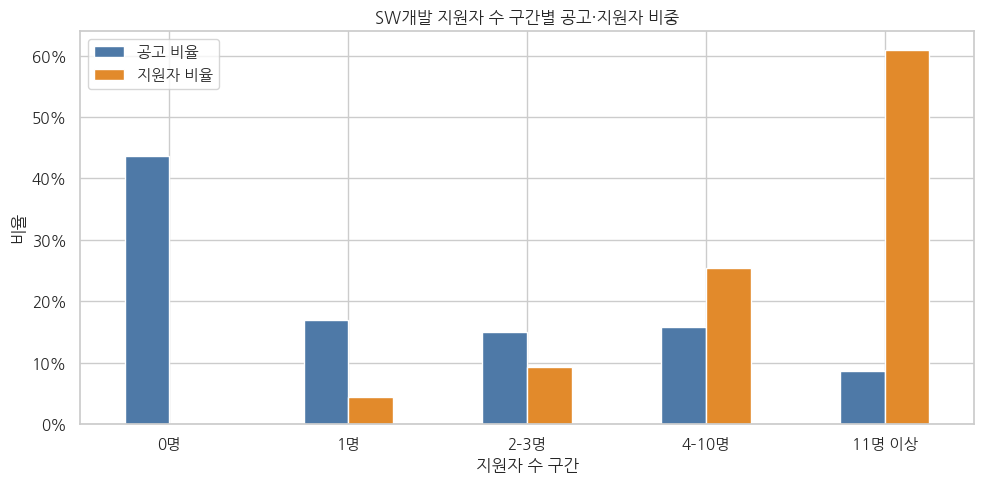

In [ ]:
# SW개발 공고만 추출하고 지원자 수 구간 순서 지정
sw_data = analysis_data[analysis_data["job_field"] == "SW 개발"].copy()
applicant_group_order = ["0명", "1명", "2–3명", "4–10명", "11명 이상"]
# 전처리 파일마다 기존 구간 라벨의 구분 기호가 다를 수 있으므로,
# 저장된 문자열을 재사용하지 않고 관측 지원자 수로 분석 구간을 다시 생성한다.
sw_data["applicant_group_analysis"] = pd.cut(
    pd.to_numeric(sw_data["observed_applicant_count_period"], errors="coerce"),
    bins=[-1, 0, 1, 3, 10, float("inf")],
    labels=applicant_group_order,
    ordered=True,
)

# 구간 생성 누락 여부와 구간별 공고 수 합계를 확인한다.
missing_group_count = int(sw_data["applicant_group_analysis"].isna().sum())
if missing_group_count > 0:
    raise ValueError(f"지원자 수 구간 생성 누락: {missing_group_count:,}건")

# 분석에 사용할 수치형 컬럼 정리
numeric_columns = [
    "allow_remote", "can_show_salary", "bookmark_count_period",
    "view_count", "follow_count", "reference_count",
    "observed_applicant_count_period",
]
for column in numeric_columns:
    if column in sw_data.columns:
        sw_data[column] = pd.to_numeric(sw_data[column], errors="coerce")

# 이후 절에서 함께 사용할 구간별 요약표
sw_group_summary = (
    sw_data.groupby("applicant_group_analysis", observed=False)
    .agg(
        job_count=("job_uuid", "nunique"),
        total_applicants=("observed_applicant_count_period", "sum"),
        avg_applicants=("observed_applicant_count_period", "mean"),
        avg_views=("view_count", "mean"),
        avg_follows=("follow_count", "mean"),
        avg_references=("reference_count", "mean"),
        total_bookmarks=("bookmark_count_period", "sum"),
        avg_bookmarks=("bookmark_count_period", "mean"),
        remote_rate=("allow_remote", "mean"),
        salary_disclosure_rate=("can_show_salary", "mean"),
        investment_info_rate=("has_investment_info_to_2023", "mean"),
        intern_rate=("is_intern", "mean"),
        entry_level_rate=("is_entry_level", "mean"),
        experienced_rate=("is_experienced", "mean"),
    )
    .reindex(applicant_group_order)
)

# 2.3: 구간별 공고 비중과 지원자 비중
group_distribution = sw_group_summary[["job_count", "total_applicants"]].copy()
group_distribution["job_share"] = group_distribution["job_count"] / group_distribution["job_count"].sum()
group_distribution["applicant_share"] = group_distribution["total_applicants"] / group_distribution["total_applicants"].sum()

display(group_distribution[["job_count", "job_share"]].style.format({
    "job_count": "{:,.0f}",
    "job_share": "{:.1%}",
}))

axis = group_distribution[["job_share", "applicant_share"]].plot(
    kind="bar", figsize=(10, 5), color=["#4E79A7", "#E28A2B"]
)
axis.set_title("SW개발 지원자 수 구간별 공고·지원자 비중")
axis.set_xlabel("지원자 수 구간")
axis.set_ylabel("비율")
axis.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axis.legend(["공고 비율", "지원자 비율"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**결과 해석**

SW 개발 공고 중 지원자 0명 공고는 **43.6%**이며, 11명 이상 공고는 **8.7%**다. 구간은 분위수(quantile)가 아니라 실제 지원 규모를 직관적으로 비교하기 위한 고정 범주다.


## 2.4 SW 공고의 지원자 수 구간별 기업·공고 특성 분석

지원자 수 구간별로 기업 인지도 지표와 공고 조건이 함께 달라지는지 확인한다. 구간은 결과를 설명하기 위한 기술적 분류이며 성과 등급이 아니다.


In [ ]:
# 2.4: 구간별 공고 수, 총 지원자 수, 평균 지원자 수
display(
    sw_group_summary[["job_count", "total_applicants", "avg_applicants"]]
    .rename(columns={
        "job_count": "공고 수",
        "total_applicants": "총 지원자 수",
        "avg_applicants": "평균 지원자 수",
    })
    .style.format({
        "공고 수": "{:,.0f}",
        "총 지원자 수": "{:,.0f}",
        "평균 지원자 수": "{:.2f}",
    })
)


,공고 수,총 지원자 수,평균 지원자 수
applicant_group_analysis,,,
0명,"5,810",0,0.00
1명,"2,253","2,253",1.00
2–3명,"1,993","4,774",2.40
4–10명,"2,108","12,968",6.15
11명 이상,"1,160","31,152",26.86


### 2.4.1 구간별 기업 특성 지표 비교

기업 조회·팔로우·추천 수를 비교한다. 평균값은 일부 대형 기업의 영향을 받을 수 있으므로 인과적 효과로 해석하지 않는다.


In [ ]:
# 지원자 수 구간별 기업 특성 지표
company_feature_summary = (
    sw_data.groupby("applicant_group_analysis", observed=False)
    .agg(
        평균_기업_정보_조회수=("view_count", "mean"),
        평균_기업_팔로우_수=("follow_count", "mean"),
        평균_기업_추천_수=("reference_count", "mean"),
    )
    .reindex(applicant_group_order)
)
display(company_feature_summary.style.format("{:,.2f}"))


,평균_기업_정보_조회수,평균_기업_팔로우_수,평균_기업_추천_수
applicant_group_analysis,,,
0명,"9,848.39",180.33,9.45
1명,"10,024.02",163.16,8.18
2–3명,"9,718.89",158.55,7.72
4–10명,"9,916.96",168.13,7.88
11명 이상,"10,262.71",238.67,9.27


### 2.4.2 구간별 공고 특성 지표 비교

원격근무, 연봉·투자정보 공개, 경력 조건, 북마크를 비교한다. 지원자 수 구간과 함께 나타나는 패턴을 찾는 탐색적 분석이다.


In [ ]:
# 원격근무·연봉·투자정보·경력 조건 비교
posting_feature_summary = sw_group_summary[[
    "remote_rate", "salary_disclosure_rate", "investment_info_rate",
    "intern_rate", "entry_level_rate", "experienced_rate",
]].rename(columns={
    "remote_rate": "원격근무 비율",
    "salary_disclosure_rate": "연봉 공개 비율",
    "investment_info_rate": "투자정보 공개 비율",
    "intern_rate": "인턴 포함 공고 비율",
    "entry_level_rate": "신입 포함 공고 비율",
    "experienced_rate": "경력 포함 공고 비율",
})
display(posting_feature_summary.style.format("{:.1%}"))

# 2.4에서 북마크 지표도 함께 비교하고, 3.1에서 상세 분석한다.
bookmark_summary = sw_group_summary[["total_bookmarks", "avg_bookmarks"]].rename(columns={
    "total_bookmarks": "총 북마크 수",
    "avg_bookmarks": "평균 북마크 수",
})
display(bookmark_summary.style.format({
    "총 북마크 수": "{:,.0f}",
    "평균 북마크 수": "{:.2f}",
}))


,원격근무 비율,연봉 공개 비율,투자정보 공개 비율,인턴 포함 공고 비율,신입 포함 공고 비율,경력 포함 공고 비율
applicant_group_analysis,,,,,,
0명,16.7%,27.8%,38.9%,3.4%,24.5%,97.0%
1명,22.7%,31.6%,43.1%,4.0%,29.2%,97.2%
2–3명,25.7%,31.9%,42.1%,7.2%,38.1%,95.7%
4–10명,23.7%,36.4%,46.3%,10.7%,47.7%,93.0%
11명 이상,21.2%,34.7%,51.4%,12.2%,61.0%,92.4%


,총 북마크 수,평균 북마크 수
applicant_group_analysis,,
0명,"2,574",0.44
1명,"2,852",1.27
2–3명,"4,740",2.38
4–10명,"10,956",5.20
11명 이상,"22,355",19.27


#**기업·공고 특성 종합**

- 기업 조회·팔로우·추천 평균은 구간별로 일부 차이가 있지만 일관된 단조 증가 패턴은 제한적이다.
- 투자정보 공개 비율은 0명 구간 **38.9%**에서 11명 이상 구간 **51.4%**로 높아진다.
- 신입 포함 공고 비율은 0명 구간 **24.5%**에서 11명 이상 구간 **61.0%**로 높아진다.
- 공고당 평균 북마크는 0명 구간 **0.44건**, 11명 이상 구간 **19.27건**이다.

이 차이는 관련성 탐색 결과다. 기업 인지도, 공고 매력도, 노출량 등 관찰되지 않은 요인이 북마크와 지원에 함께 영향을 줄 수 있다.


## 2.5 추가분석 대상 선정

기업·공고 특성 중 일부 지표는 지원자 수 구간에 따라 차이를 보였다. 다만 이러한 특성은 기업의 채용 조건에 가까워 플랫폼이 직접 개입하기 어렵다. 반면 북마크는 사용자의 관심을 나타내는 플랫폼 내 행동 지표이므로, 지원과의 관계 및 북마크 이후 행동을 추가로 살펴본다.


## 3.1 북마크 지표 추가 분석

북마크가 공고별 지원자 수와 함께 증가하는지 확인한다. 이 결과는 북마크가 지원을 유발했다는 증거가 아니라 추가 행동 분석 대상을 고르는 근거다.


#### 지원자 수 구간별 북마크 지표

,공고_수,북마크_합계,공고당_평균_북마크,공고당_중앙_북마크,북마크_0건_공고_비율
applicant_group_analysis,,,,,
0명,"5,810","2,574",0.44,0,73.7%
1명,"2,253","2,852",1.27,1,40.4%
2–3명,"1,993","4,740",2.38,2,20.4%
4–10명,"2,108","10,956",5.20,4,6.2%
11명 이상,"1,160","22,355",19.27,13,0.3%


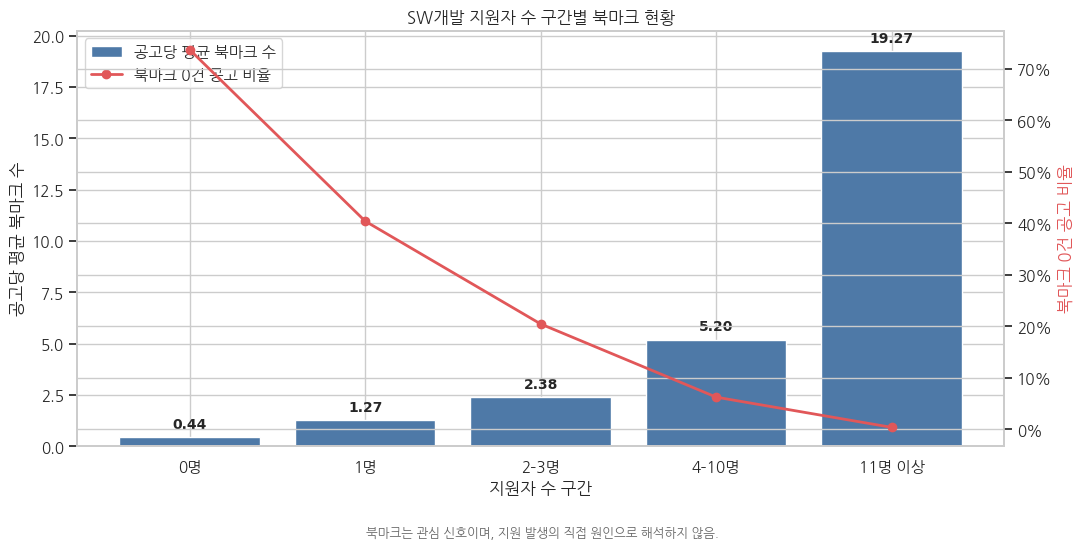

In [ ]:
# 지원자 수 구간별 북마크 집계 생성
bookmark_group_summary = (
    sw_data.groupby("applicant_group_analysis", observed=False)
    .agg(
        공고_수=("job_uuid", "nunique"),
        북마크_합계=("bookmark_count_period", "sum"),
        공고당_평균_북마크=("bookmark_count_period", "mean"),
        공고당_중앙_북마크=("bookmark_count_period", "median"),
        북마크_0건_공고_비율=("bookmark_count_period", lambda values: (values == 0).mean()),
    )
    .reindex(applicant_group_order)
)
display(Markdown("#### 지원자 수 구간별 북마크 지표"))
display(bookmark_group_summary.style.format({
    "공고_수": "{:,.0f}",
    "북마크_합계": "{:,.0f}",
    "공고당_평균_북마크": "{:.2f}",
    "공고당_중앙_북마크": "{:.0f}",
    "북마크_0건_공고_비율": "{:.1%}",
}))
print("\n")

# 공고당 평균 북마크 수와 북마크 0건 공고 비율 시각화
figure, left_axis = plt.subplots(figsize=(11, 5.5))
positions = list(range(len(bookmark_group_summary)))
bookmark_bars = left_axis.bar(
    positions,
    bookmark_group_summary["공고당_평균_북마크"],
    color="#4E79A7",
    label="공고당 평균 북마크 수",
)
left_axis.set_ylabel("공고당 평균 북마크 수")
left_axis.set_xlabel("지원자 수 구간")
left_axis.set_xticks(positions, applicant_group_order)
for bar in bookmark_bars:
    left_axis.annotate(
        "{:.2f}".format(bar.get_height()),
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        fontfamily="DejaVu Sans",
    )
right_axis = left_axis.twinx()
right_axis.plot(
    positions,
    bookmark_group_summary["북마크_0건_공고_비율"],
    color="#E15759",
    marker="o",
    linewidth=2,
    label="북마크 0건 공고 비율",
)
right_axis.set_ylabel("북마크 0건 공고 비율", color="#E15759")
right_axis.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
left_axis.set_title("SW개발 지원자 수 구간별 북마크 현황")
handles_left, labels_left = left_axis.get_legend_handles_labels()
handles_right, labels_right = right_axis.get_legend_handles_labels()
left_axis.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")
figure.text(0.5, 0.01, "북마크는 관심 신호이며, 지원 발생의 직접 원인으로 해석하지 않음.", ha="center", fontsize=9, color="#666666")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**추가 분석 판단**

지원자가 많은 구간일수록 공고당 북마크가 함께 증가하고 북마크 0건 공고 비율은 낮아진다. 그러나 이 결과만으로 북마크가 지원을 만들었다고 판단할 수 없다. **매력적인 공고가 북마크와 지원을 모두 높였을 가능성**이 있으므로, 다음 단계에서는 북마크한 공고와 실제 지원을 사용자–공고 단위로 연결한다.


## 3.2 북마크 이후 행동 경로 분석

북마크한 공고와 이후 지원의 연결을 사용자–공고 조합으로 확인하고, 북마크 뒤에 관찰되는 URL 행동을 비교한다.


In [ ]:
# SW 개발 공고의 북마크·지원 원천 데이터를 불러온다.
from pathlib import Path

def find_input_file(file_name):
    candidates = [work_dir / file_name, *Path.cwd().rglob(file_name)]
    return next(path for path in candidates if path.exists())

bookmark_data = pd.read_csv(find_input_file("sw_bookmarks_2022_2023.csv"))
application_data = pd.read_csv(find_input_file("sw_applications_2022_2023.csv"))
bookmark_data["bookmark_time_kst"] = pd.to_datetime(
    bookmark_data["bookmark_cdate"], errors="coerce", utc=True
).dt.tz_convert("Asia/Seoul")
application_data["application_time_kst"] = pd.to_datetime(
    application_data["application_cdate"], errors="coerce", utc=True
).dt.tz_convert("Asia/Seoul")

bookmark_first = bookmark_data.sort_values("bookmark_time_kst").drop_duplicates(
    ["user_uuid", "job_uuid"], keep="first"
)
application_first = application_data.sort_values("application_time_kst").drop_duplicates(
    ["user_uuid", "job_uuid"], keep="first"
)
bookmark_funnel = bookmark_first.merge(
    application_first, on=["user_uuid", "job_uuid"], how="left"
)
bookmark_funnel["is_applied_after_bookmark"] = (
    bookmark_funnel["application_time_kst"].notna()
    & (bookmark_funnel["application_time_kst"] >= bookmark_funnel["bookmark_time_kst"])
)
bookmark_funnel["days_to_application"] = (
    bookmark_funnel["application_time_kst"] - bookmark_funnel["bookmark_time_kst"]
).dt.total_seconds() / 86400
bookmark_funnel["observation_days_to_period_end"] = (
    analysis_end_date_exclusive.tz_localize("Asia/Seoul")
    - bookmark_funnel["bookmark_time_kst"]
).dt.total_seconds() / 86400

funnel_total = len(bookmark_funnel)
funnel_applied = int(bookmark_funnel["is_applied_after_bookmark"].sum())
funnel_summary = pd.DataFrame({
    "단계": ["SW 개발 공고 북마크", "북마크 후 지원 완료", "북마크 후 미지원·관측 종료"],
    "건수": [funnel_total, funnel_applied, funnel_total - funnel_applied],
})
funnel_summary["단계 비율"] = funnel_summary["건수"] / funnel_total
print(f"북마크-공고 조합 수: {funnel_total:,}건")
print(f"북마크 고유 사용자 수: {bookmark_funnel['user_uuid'].nunique():,}명")
display(funnel_summary.style.format({"건수": "{:,.0f}", "단계 비율": "{:.1%}"}))

duration_summary = (
    bookmark_funnel.loc[bookmark_funnel["is_applied_after_bookmark"], "days_to_application"]
    .describe(percentiles=[.5, .75, .9, .95])
    .rename({"50%": "median", "75%": "p75", "90%": "p90", "95%": "p95"})
    .to_frame("북마크 후 지원까지 일수")
)
print("\n북마크 후 지원까지 걸린 시간")
display(duration_summary)

matured_bookmarks = bookmark_funnel.loc[
    bookmark_funnel["bookmark_time_kst"] < pd.Timestamp("2023-12-01", tz="Asia/Seoul")
].copy()
matured_30d_conversion = (
    matured_bookmarks["is_applied_after_bookmark"]
    & matured_bookmarks["days_to_application"].le(30)
).mean()
print(f"2023-12-01 이전 북마크의 30일 내 지원 전환율: {matured_30d_conversion:.1%}")
print("지원서 작성 단계별 병목은 로그의 job_uuid 연결 가능 여부를 확인한 뒤 별도 분석한다.")

**북마크–동일 공고 지원 현황**

- 북마크–공고 조합은 **55,823건**, 북마크 고유 사용자는 **8,531명**이다.
- 북마크 후 동일 공고 지원이 확인된 경로는 **5,714건**이다.
- 2023-12-01 이전 북마크 중 30일 내 동일 공고 지원 전환율은 **9.4%**다.
- 전환 경로의 지원까지 걸린 시간 중앙값은 약 **2일**이다.

전환율의 분모는 고유 사용자가 아니라 **사용자–공고 조합**이다. 지원하지 않은 이유와 북마크의 인과 효과는 이 결과로 확인할 수 없다.


### 3.2.1 행동 경로 세그먼트 정의

- **세그먼트 A:** 북마크한 공고 A에 북마크 이후 지원한 경로
- **세그먼트 B:** 공고 A에는 지원하지 않았지만 이후 다른 SW 개발 공고에 지원한 경로
- **세그먼트 C:** 공고 A에 지원하지 않았고 북마크 후 30일 동안 다른 SW 개발 공고 지원도 확인되지 않은 경로

> 세그먼트는 사용자–공고 경로를 기준으로 생성한다. 같은 사용자가 서로 다른 공고에서 여러 경로를 가질 수 있으므로 완전히 상호배타적인 사용자 집단으로 해석하지 않는다.


### 3.2.2 분석 기준 및 분모

- 세그먼트 규모: 북마크·지원 이벤트에서 확인한 사용자–공고 경로
- 행동 도달률 분모: 각 세그먼트에서 URL 로그가 실제로 관찰된 고유 사용자
- URL 호출 비율 분모: 각 세그먼트에서 관찰된 전체 정규화 URL 호출
- 관찰 기간: A는 북마크부터 동일 공고 지원까지, B·C는 A 미지원 북마크 후 30일

> A와 B·C의 관찰창 길이가 다르므로 행동 빈도 차이는 기술적 비교로만 사용한다.


#### 3.2.2.1 행동 분류 기준

URL 행동은 의미가 명확한 경우에만 탐색, 관심, 지원 준비로 분류한다.


In [ ]:
# 전체 URL 행동 로그 불러오기.
all_action_file_candidates = [
    work_dir / "sw_a_nonconversion_all_action_logs_2022_2023.csv.gz",
    *Path.cwd().rglob("SW개발_A공고_북마크후_동일공고미지원_전체행동로그_2022_2023.csv.gz"),
]
all_action_file = next((path for path in all_action_file_candidates if path.exists()), None)
if all_action_file is None:
    raise FileNotFoundError("A 공고 미지원 사용자의 전체 행동 로그 파일을 찾지 못함")

a_nonconversion_all_actions = pd.read_csv(
    all_action_file, compression="infer", low_memory=False
)
print(f"대상 사용자 수: {a_nonconversion_all_actions['user_uuid'].nunique():,}명")
print(f"전체 성공 URL 로그 수: {len(a_nonconversion_all_actions):,}건")


대상 사용자 수: 3,656명
전체 성공 URL 로그 수: 1,498,393건


In [ ]:
# 쿼리스트링과 동적 식별자를 제거해 같은 URL 행동으로 정규화
def normalize_url_type(value):
    text = "" if pd.isna(value) else str(value).strip().lower()
    text = text.split("?", 1)[0].split("#", 1)[0]
    text = re.sub(
        r"[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}",
        "{uuid}", text,
    )
    text = re.sub(r"(?<=/)[0-9]+(?=/|$)", "{id}", text)
    return text.rstrip("/") or "/"

valid_url_actions = a_nonconversion_all_actions.copy()
valid_url_actions["path_clean"] = valid_url_actions["path"].astype("string").str.strip()
valid_url_actions = valid_url_actions[
    valid_url_actions["path_clean"].notna()
    & valid_url_actions["path_clean"].ne("")
    & valid_url_actions["path_clean"].str.lower().ne("nan")
].copy()
valid_url_actions["url_type"] = valid_url_actions["path_clean"].map(normalize_url_type)

url_behavior_labels = {
    "jobs/id/id_title": "공고 상세 페이지 조회",
    "api/jobs/id/other_jobs": "유사·다른 공고 목록 요청",
    "api/jobs/job_title": "직무명·조건 공고 검색",
    "api/users/id/template": "사용자 템플릿 API 요청",
    "@user_id": "사용자 프로필 조회·수정 진입",
    "api/recommend_specialty": "전문분야 기반 추천 요청",
    "@user_id/applications": "내 지원 현황 조회",
    "suggest": "검색어 자동완성·제안",
    "companies/company_id/jobs": "기업의 공고 목록 조회",
    "api/users/id/experience/form": "이력·경력 입력 양식 요청",
    "companies/company_id": "기업 정보 페이지 조회",
    "api/companies/id/view": "기업 정보 API 요청",
    "jobs": "공고 목록·탐색 화면 조회",
    "api/jobs/id/bookmark": "공고 북마크 API 요청",
}


#### 3.2.2.2 세그먼트별 관찰 대상 및 분모

세그먼트 규모는 북마크·지원 이벤트의 사용자–공고 쌍을 기준으로 집계한다. 이후 행동 패턴은 URL 로그가 확인되는 사용자만 관찰할 수 있으므로, 각 결과에 표시된 관찰 사용자 수를 분모로 사용한다.


### 3.2.3 세그먼트별 북마크 후 상위 행동 패턴

세 세그먼트 모두 정규화 URL 유형별 **URL 호출 수 내림차순**으로 TOP 10을 선정한다. 고유 사용자 수·도달률·사용자당 평균 호출 수는 보조 지표다.


#### 3.2.3.1 세그먼트 A: A 공고 북마크 → A 공고 지원

북마크부터 동일 공고 지원까지 관찰된 URL 행동을 URL 호출 수 기준으로 집계한다.


In [ ]:
# 동일 공고 북마크→지원 여정 사이에 발생한 URL 행동 로그를 불러온다.
journey_url_candidates = [
    work_dir / "sw_bookmark_application_journey_urls_2022_2023.csv.gz",
    *Path.cwd().rglob("SW개발_북마크지원_여정URL_2022_2023.csv.gz"),
]
journey_url_candidates = list(dict.fromkeys(path for path in journey_url_candidates if path.exists()))

if not journey_url_candidates:
    raise FileNotFoundError("북마크→지원 여정 URL 로그 파일을 찾지 못함")

journey_url_logs = pd.read_csv(journey_url_candidates[0], compression="infer", low_memory=False)
journey_url_logs["event_time_kst"] = pd.to_datetime(
    journey_url_logs["event_time_kst"], errors="coerce", utc=True
)
journey_url_logs["행동 단계"] = journey_url_logs["journey_action"].replace({
    "공고 재방문": "공고 관련 탐색",
    "북마크 목록·관련 행동": "북마크 관련 화면·행동",
})

# URL 로그가 없는 전환 사용자도 분모에 포함하기 위해 전환 여정 전체를 다시 생성한다.
first_converted_journeys = bookmark_first.merge(
    application_first, on=["user_uuid", "job_uuid"], how="inner"
)
first_converted_journeys = first_converted_journeys.loc[
    first_converted_journeys["application_time_kst"] >= first_converted_journeys["bookmark_time_kst"]
].sort_values(["user_uuid", "bookmark_time_kst", "application_time_kst"])
first_converted_journeys = first_converted_journeys.drop_duplicates("user_uuid", keep="first")
journey_user_count = len(first_converted_journeys)
logged_journey_user_count = journey_url_logs["user_uuid"].nunique()
print(f"분석 여정 수(사용자별 첫 동일 공고 전환): {journey_user_count:,}명")
print(f"URL 행동이 관측된 전환 사용자 수: {logged_journey_user_count:,}명")
print(f"북마크~지원 사이 URL 행동 로그 수: {len(journey_url_logs):,}건")


분석 여정 수(사용자별 첫 동일 공고 전환): 1,972명
URL 행동이 관측된 전환 사용자 수: 1,970명
북마크~지원 사이 URL 행동 로그 수: 340,783건


In [ ]:
# 동일 공고 전환 여정의 전체 URL을 정규화하고 상위 10개 행동으로 집계.
def normalize_journey_url(value):
    text = "" if pd.isna(value) else str(value).strip().lower()
    text = text.split("?", 1)[0].split("#", 1)[0]
    text = re.sub(
        r"[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}",
        "{uuid}",
        text,
    )
    text = re.sub(r"(?<=/)[0-9]+(?=/|$)", "{id}", text)
    return text.rstrip("/") or "/"

journey_all_urls = journey_url_logs.copy()
journey_all_urls["url_clean"] = journey_all_urls["url"].astype("string").str.strip()
journey_all_urls = journey_all_urls.loc[
    journey_all_urls["url_clean"].notna()
    & journey_all_urls["url_clean"].ne("")
    & journey_all_urls["url_clean"].str.lower().ne("nan")
].copy()
journey_all_urls["정규화 URL 유형"] = journey_all_urls["url_clean"].map(normalize_journey_url)

journey_url_meanings = {
    "jobs/id/id_title": "공고 상세 페이지 조회",
    "api/jobs/id/other_jobs": "유사·다른 공고 목록 요청",
    "api/jobs/job_title": "직무명·조건 공고 검색",
    "api/users/id/experience/form": "이력·경력 입력 양식 요청",
    "companies/company_id/jobs": "기업의 공고 목록 조회",
    "companies/company_id": "기업 정보 페이지 조회",
    "api/companies/id/view": "기업 정보 API 요청",
    "api/jobs/id/bookmark": "공고 북마크 API 요청",
    "jobs/id/apply/step1": "지원서 작성 1단계",
    "jobs/id/apply/step2": "지원서 작성 2단계",
}

journey_top10_urls = (
    journey_all_urls.groupby("정규화 URL 유형", dropna=False)
    .agg(
        URL_호출_수=("url", "size"),
        고유_사용자_수=("user_uuid", "nunique"),
    )
    .sort_values("URL_호출_수", ascending=False)
    .head(10)
    .reset_index()
)
journey_top10_urls["대표 행동"] = (
    journey_top10_urls["정규화 URL 유형"].map(journey_url_meanings).fillna("기능 확인 필요")
)
journey_top10_urls["사용자당 평균 URL 호출"] = (
    journey_top10_urls["URL_호출_수"] / journey_top10_urls["고유_사용자_수"]
)

# 표의 순위를 1위부터 표시한다.
journey_top10_urls.index = pd.RangeIndex(start=1, stop=len(journey_top10_urls) + 1, name="순위")

print(f"대상 전환 사용자 수: {journey_user_count:,}명")
print(f"URL 행동 관측 사용자 수: {journey_all_urls['user_uuid'].nunique():,}명")
display(Markdown("#### 세그먼트 A(동일 공고 북마크→지원 여정)의 URL 행동 상위 10개"))
display(
    journey_top10_urls.style.format(
        {
            "URL_호출_수": "{:,}",
            "고유_사용자_수": "{:,}",
            "사용자당 평균 URL 호출": "{:.1f}",
        }
    )
)


대상 전환 사용자 수: 1,972명
URL 행동 관측 사용자 수: 1,970명


#### 세그먼트 A(동일 공고 북마크→지원 여정)의 URL 행동 상위 10개

,정규화 URL 유형,URL_호출_수,고유_사용자_수,대표 행동,사용자당 평균 URL 호출
순위,,,,,
1,jobs/id/id_title,"54,913","1,681",공고 상세 페이지 조회,32.7
2,api/jobs/id/other_jobs,"49,860","1,666",유사·다른 공고 목록 요청,29.9
3,api/jobs/job_title,"33,166","1,384",직무명·조건 공고 검색,24.0
4,api/users/id/experience/form,"26,763","1,811",이력·경력 입력 양식 요청,14.8
5,companies/company_id/jobs,"17,544","1,332",기업의 공고 목록 조회,13.2
6,companies/company_id,"11,812","1,200",기업 정보 페이지 조회,9.8
7,jobs/id/apply/step1,"11,615","1,919",지원서 작성 1단계,6.1
8,api/companies/id/view,"11,396","1,191",기업 정보 API 요청,9.6
9,api/jobs/id/bookmark,"11,208","1,377",공고 북마크 API 요청,8.1


**세그먼트 A 해석 기준**

상위 행동에는 공고 탐색과 지원 준비가 함께 나타난다. 지원서 작성 단계가 상위권에 포함되는 것은 세그먼트가 결과적으로 동일 공고에 지원한 경로이기 때문에 예상 가능한 패턴이다. 이를 지원 성공의 원인으로 해석하지 않는다.


#### 3.2.3.2 세그먼트 B: A 공고 미지원 → 다른 SW 공고 지원

A 공고 미지원 북마크 후 30일 동안 관찰된 URL 행동을 URL 호출 수 기준으로 집계한다.


In [ ]:
# A 미지원 이후 다른 SW 공고에 지원한 사용자만 분리해 동일 기준으로 상위 URL 행동 집계.
other_job_actions = valid_url_actions.loc[
    valid_url_actions["post_bookmark_status"].eq("A 미지원·다른 SW 공고 지원")
].copy()
other_job_top10 = (
    other_job_actions.groupby("url_type", dropna=False)
    .agg(
        URL_호출_수=("path", "size"),
        고유_사용자_수=("user_uuid", "nunique"),
    )
    .sort_values("URL_호출_수", ascending=False)
    .head(10)
    .reset_index()
)
other_job_top10["대표 행동"] = (
    other_job_top10["url_type"].map(url_behavior_labels).fillna("기능 확인 필요")
)
other_job_top10["사용자당_평균_URL_호출"] = (
    other_job_top10["URL_호출_수"] / other_job_top10["고유_사용자_수"]
)

# 표의 순위를 1위부터 표시한다.
other_job_top10.index = pd.RangeIndex(start=1, stop=len(other_job_top10) + 1, name="순위")

print(f"대상 사용자 수: {other_job_actions['user_uuid'].nunique():,}명")
display(Markdown("#### 세그먼트 B(A 공고 미지원→다른 SW 공고 지원)의 URL 행동 상위 10개"))
display(
    other_job_top10.rename(columns={"url_type": "정규화 URL 유형"}).style.format(
        {
            "URL_호출_수": "{:,}",
            "고유_사용자_수": "{:,}",
            "사용자당_평균_URL_호출": "{:.1f}",
        }
    )
)

print("\n해석 기준: 이 집단은 A 공고에는 미지원이지만 다른 공고에는 지원한 사용자이다. URL 로그만으로 A를 포기한 이유를 확정하지 않는다.")


대상 사용자 수: 1,809명


#### 세그먼트 B(A 공고 미지원→다른 SW 공고 지원)의 URL 행동 상위 10개

,정규화 URL 유형,URL_호출_수,고유_사용자_수,대표 행동,사용자당_평균_URL_호출
순위,,,,,
1,jobs/id/id_title,"114,792","1,797",공고 상세 페이지 조회,63.9
2,api/jobs/id/other_jobs,"104,029","1,792",유사·다른 공고 목록 요청,58.1
3,api/jobs/job_title,"75,226","1,748",직무명·조건 공고 검색,43.0
4,api/users/id/template,"62,609","1,742",사용자 템플릿 API 요청,35.9
5,api/recommend_specialty,"55,085","1,808",전문분야 기반 추천 요청,30.5
6,@user_id,"53,318","1,736",사용자 프로필 조회·수정 진입,30.7
7,@user_id/applications,"51,971","1,704",내 지원 현황 조회,30.5
8,api/users/id/experience/form,"40,443","1,707",이력·경력 입력 양식 요청,23.7
9,companies/company_id/jobs,"36,953","1,738",기업의 공고 목록 조회,21.3



해석 기준: 이 집단은 A 공고에는 미지원이지만 다른 공고에는 지원한 사용자이다. URL 로그만으로 A를 포기한 이유를 확정하지 않는다.


**세그먼트 B 해석 기준**

공고 상세 조회·유사 공고 탐색·직무 검색과 함께 추천·프로필·지원 현황 조회가 나타난다. 이는 A 공고 이후 다른 대안을 탐색하고 지원한 경로에서 관찰된 행동이며, A 공고를 포기한 이유를 직접 보여주지는 않는다.


#### 3.2.3.3 세그먼트 C: A 공고 미지원 → 30일 내 다른 SW 공고도 미지원

A 공고 미지원 북마크 후 30일 동안 관찰된 URL 행동을 URL 호출 수 기준으로 집계한다. 행동 도달률과 사용자당 평균 호출 수는 선정 기준이 아닌 보조 지표다.


**세그먼트 C 해석 기준**

이 집단은 북마크 후 30일 동안 SW 개발 지원이 확인되지 않은 경로다. URL 로그가 관찰된 사용자만 행동 분석에 포함되므로, 전체 C 경로의 행동을 대표한다고 단정하지 않는다. 또한 지원 미확인의 원인을 개별 URL 행동만으로 확정하지 않는다.

In [ ]:
# A 공고 북마크 후 30일 내 SW 공고에 지원하지 않은 사용자만 분리한다.
no_sw_application_status = "A 미지원·30일 내 SW 지원 없음"
no_sw_application_actions = valid_url_actions.loc[
    valid_url_actions["post_bookmark_status"].eq(no_sw_application_status)
].copy()
no_sw_application_cohort_user_count = a_nonconversion_cohort.loc[
    a_nonconversion_cohort["post_bookmark_status"].eq(no_sw_application_status),
    "user_uuid",
].nunique()
no_sw_application_log_user_count = no_sw_application_actions["user_uuid"].nunique()

# 정규화 URL 유형별 호출 수·행동 사용자 수·도달률을 집계한다.
no_sw_application_url_summary = (
    no_sw_application_actions.groupby("url_type", dropna=False)
    .agg(
        URL_호출_수=("path", "size"),
        행동_사용자_수=("user_uuid", "nunique"),
    )
    .reset_index()
)

# URL 행동 도달률은 URL 로그가 실제로 관측된 사용자만 분모로 사용한다.
no_sw_application_url_summary["로그_관측_사용자_기준_행동_도달률"] = (
    no_sw_application_url_summary["행동_사용자_수"] / no_sw_application_log_user_count
)
no_sw_application_url_summary["행동_사용자_1명당_평균_URL_호출"] = (
    no_sw_application_url_summary["URL_호출_수"]
    / no_sw_application_url_summary["행동_사용자_수"]
)
no_sw_application_url_summary["대표 행동"] = (
    no_sw_application_url_summary["url_type"]
    .map(url_behavior_labels)
    .fillna("기능 확인 필요")
)

# 세그먼트 A·B와 동일하게 URL 호출 수를 기준으로 상위 10개 URL 유형을 선정한다.
no_sw_application_top10 = (
    no_sw_application_url_summary
    .sort_values("URL_호출_수", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# 표의 순위를 1위부터 표시한다.
no_sw_application_top10.index = pd.RangeIndex(start=1, stop=len(no_sw_application_top10) + 1, name="순위")

print(f"코호트 전체 사용자 수: {no_sw_application_cohort_user_count:,}명")
print(f"URL 로그 관측 사용자 수: {no_sw_application_log_user_count:,}명")
print(f"URL 로그 관측 비율: {no_sw_application_log_user_count / no_sw_application_cohort_user_count:.1%}")
print(f"30일 내 정규화 URL 행동 수: {len(no_sw_application_actions):,}건")
display(Markdown("#### 세그먼트 C(A 공고 미지원→30일 내 다른 SW 공고도 미지원)의 URL 행동 상위 10개"))
display(
    no_sw_application_top10.rename(columns={"url_type": "정규화 URL 유형"}).style.format(
        {
            "URL_호출_수": "{:,}",
            "행동_사용자_수": "{:,}",
            "로그_관측_사용자_기준_행동_도달률": "{:.1%}",
            "행동_사용자_1명당_평균_URL_호출": "{:.1f}",
        }
    )
)

print(
    "\n선정 기준: 세그먼트 A·B와 동일하게 URL 호출 수가 많은 순으로 상위 10개를 선정한다. "
    "행동 도달률은 URL 로그 관측 사용자 중 해당 URL 유형을 1회 이상 사용한 비율로 보조 해석한다."
)

코호트 전체 사용자 수: 6,285명
URL 로그 관측 사용자 수: 1,845명
URL 로그 관측 비율: 29.4%
30일 내 정규화 URL 행동 수: 318,557건


#### 세그먼트 C(A 공고 미지원→30일 내 다른 SW 공고도 미지원)의 URL 행동 상위 10개

,정규화 URL 유형,URL_호출_수,행동_사용자_수,로그_관측_사용자_기준_행동_도달률,행동_사용자_1명당_평균_URL_호출,대표 행동
순위,,,,,,
1,jobs/id/id_title,"36,479","1,590",86.2%,22.9,공고 상세 페이지 조회
2,api/jobs/id/other_jobs,"32,662","1,568",85.0%,20.8,유사·다른 공고 목록 요청
3,api/jobs/job_title,"32,009","1,400",75.9%,22.9,직무명·조건 공고 검색
4,api/users/id/template,"20,639","1,336",72.4%,15.4,사용자 템플릿 API 요청
5,@user_id,"19,971","1,396",75.7%,14.3,사용자 프로필 조회·수정 진입
6,suggest,"12,887",843,45.7%,15.3,검색어 자동완성·제안
7,companies/company_id/jobs,"12,362","1,355",73.4%,9.1,기업의 공고 목록 조회
8,jobs,"11,703","1,266",68.6%,9.2,공고 목록·탐색 화면 조회
9,companies/company_id,"10,558","1,279",69.3%,8.3,기업 정보 페이지 조회



선정 기준: 세그먼트 A·B와 동일하게 URL 호출 수가 많은 순으로 상위 10개를 선정한다. 행동 도달률은 URL 로그 관측 사용자 중 해당 URL 유형을 1회 이상 사용한 비율로 보조 해석한다.


#### **3.2.3.4 세그먼트별 분석 대상 및 로그 관찰 현황**

세그먼트 전체 사용자 수와 URL 로그가 실제로 관찰된 사용자 수를 함께 제시한다. 이후 행동 비교는 전체 세그먼트가 아니라 **URL 로그 관찰 사용자**를 기준으로 해석한다.


In [ ]:
# 세그먼트별 전체 사용자와 URL 로그 관찰 사용자를 한 표로 정리
segment_b_status = "A 미지원·다른 SW 공고 지원"
segment_b_total_users = a_nonconversion_cohort.loc[
    a_nonconversion_cohort["post_bookmark_status"].eq(segment_b_status),
    "user_uuid",
].nunique()
segment_b_logged_users = other_job_actions["user_uuid"].nunique()

segment_coverage = pd.DataFrame(
    [
        (
            "A",
            "A 공고 북마크 후 동일 A 공고 지원",
            int(journey_user_count),
            int(logged_journey_user_count),
        ),
        (
            "B",
            "A 공고 미지원 후 다른 SW 공고 지원",
            int(segment_b_total_users),
            int(segment_b_logged_users),
        ),
        (
            "C",
            "A 공고 미지원 후 30일 내 다른 SW 공고도 미지원",
            int(no_sw_application_cohort_user_count),
            int(no_sw_application_log_user_count),
        ),
    ],
    columns=["세그먼트", "정의", "전체 사용자 수", "URL 로그 관찰 사용자 수"],
)
segment_coverage["URL 로그 관찰률"] = (
    segment_coverage["URL 로그 관찰 사용자 수"]
    / segment_coverage["전체 사용자 수"]
)

display(
    segment_coverage.style.format(
        {
            "전체 사용자 수": "{:,}",
            "URL 로그 관찰 사용자 수": "{:,}",
            "URL 로그 관찰률": "{:.1%}",
        }
    )
)
print(
    "\n해석 기준: 행동 도달률과 URL 호출 비율은 URL 로그가 관찰된 사용자만 대상으로 계산한다. "
    "특히 세그먼트 C의 결과를 전체 미지원 사용자에게 일반화하지 않는다."
)


,세그먼트,정의,전체 사용자 수,URL 로그 관찰 사용자 수,URL 로그 관찰률
0,A,A 공고 북마크 후 동일 A 공고 지원,"1,972","1,970",99.9%
1,B,A 공고 미지원 후 다른 SW 공고 지원,"1,809","1,809",100.0%
2,C,A 공고 미지원 후 30일 내 다른 SW 공고도 미지원,"6,285","1,845",29.4%



해석 기준: 행동 도달률과 URL 호출 비율은 URL 로그가 관찰된 사용자만 대상으로 계산한다. 특히 세그먼트 C의 결과를 전체 미지원 사용자에게 일반화하지 않는다.


### 3.2.4 세그먼트 A·B·C 행동 비교

동일 공고 지원 경로 A와 30일 내 지원 미확인 경로 C를 비교한다. 세그먼트 B는 다른 공고에 지원한 경로로 참고표에 함께 제시한다.

> 비교 결과는 행동의 동반 출현을 보여준다. 로그 관찰률과 관찰 기간이 다르므로 전환 효과나 병목의 원인으로 단정하지 않는다.


#### 3.2.4.1 행동 도달률·URL 호출 비율 비교

세그먼트 A의 TOP 10 행동을 공통 비교축으로 사용한다. 행동 도달률은 해당 행동을 1회 이상 수행한 사용자 비율이고, URL 호출 비율은 전체 호출 중 해당 행동이 차지한 비율이다.


,행동,A 행동 도달률,C 행동 도달률,A URL 호출 비율,C URL 호출 비율
순위,,,,,
1,공고 상세 페이지 조회,85.3%,86.2%,16.1%,11.5%
2,유사·다른 공고 목록 요청,84.6%,85.0%,14.6%,10.3%
3,직무명·조건 공고 검색,70.3%,75.9%,9.7%,10.0%
4,이력·경력 입력 양식 요청,91.9%,37.3%,7.9%,1.5%
5,기업의 공고 목록 조회,67.6%,73.4%,5.1%,3.9%
6,기업 정보 페이지 조회,60.9%,69.3%,3.5%,3.3%
7,지원서 작성 1단계,97.4%,32.2%,3.4%,0.6%
8,기업 정보 API 요청,60.5%,69.3%,3.3%,3.2%
9,공고 북마크 API 요청,69.9%,65.8%,3.3%,2.0%


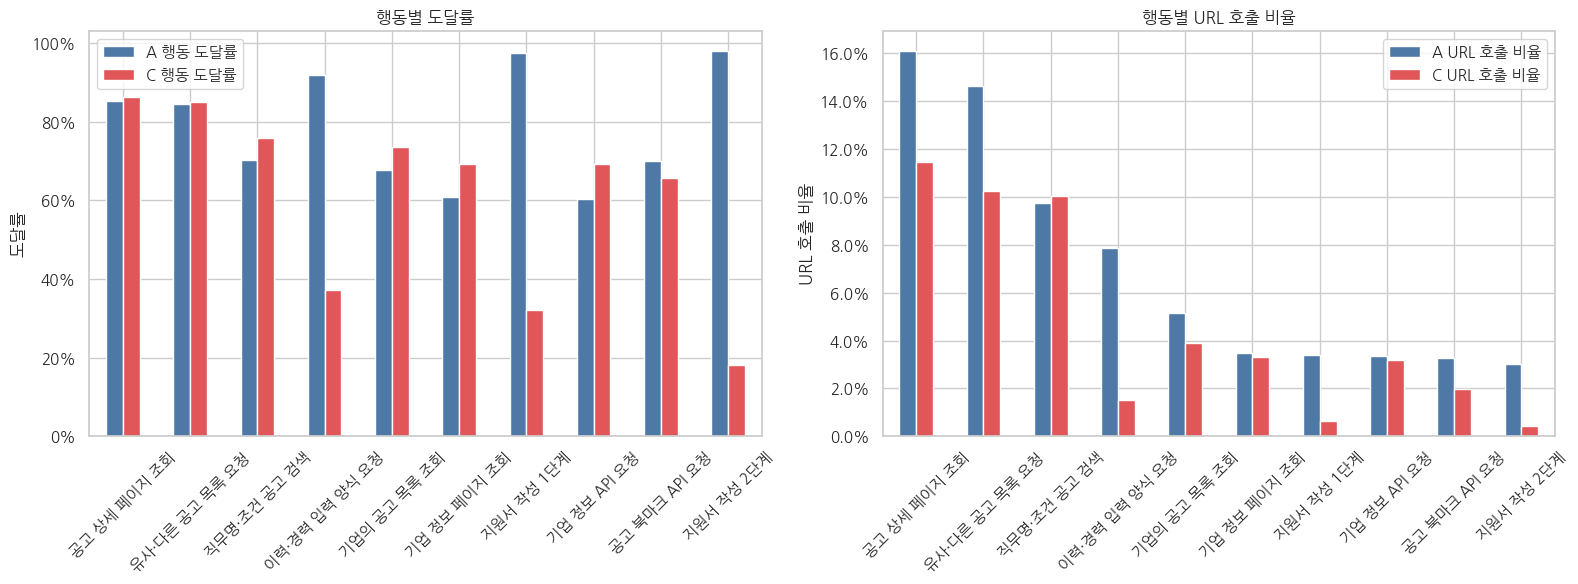

In [ ]:
# 세그먼트 A 상위 10개 행동을 기준으로 A와 C를 비교
a_top10_actions = journey_top10_urls[["정규화 URL 유형", "대표 행동"]].copy()
a_top10_actions = a_top10_actions.drop_duplicates("정규화 URL 유형")

a_user_count = journey_all_urls["user_uuid"].nunique()
c_user_count = no_sw_application_actions["user_uuid"].nunique()
a_total_calls = len(journey_all_urls)
c_total_calls = len(no_sw_application_actions)

comparison_rows = []
for _, row in a_top10_actions.iterrows():
    action_type = row["정규화 URL 유형"]
    a_action = journey_all_urls[
        journey_all_urls["정규화 URL 유형"] == action_type
    ]
    c_action = no_sw_application_actions[
        no_sw_application_actions["url_type"] == action_type
    ]
    comparison_rows.append({
        "행동": row["대표 행동"],
        "A 행동 도달률": a_action["user_uuid"].nunique() / a_user_count,
        "C 행동 도달률": c_action["user_uuid"].nunique() / c_user_count,
        "A URL 호출 비율": len(a_action) / a_total_calls,
        "C URL 호출 비율": len(c_action) / c_total_calls,
    })

ac_action_comparison = pd.DataFrame(comparison_rows)
# 비교표의 순위를 1위부터 표시한다.
ac_action_comparison.index = pd.RangeIndex(
    start=1, stop=len(ac_action_comparison) + 1, name="순위"
)
display(ac_action_comparison.style.format({
    "A 행동 도달률": "{:.1%}",
    "C 행동 도달률": "{:.1%}",
    "A URL 호출 비율": "{:.1%}",
    "C URL 호출 비율": "{:.1%}",
}))

figure, axes = plt.subplots(1, 2, figsize=(16, 6))
ac_action_comparison.plot(
    x="행동", y=["A 행동 도달률", "C 행동 도달률"],
    kind="bar", ax=axes[0], color=["#4E79A7", "#E15759"]
)
axes[0].set_title("행동별 도달률")
axes[0].set_xlabel("")
axes[0].set_ylabel("도달률")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].tick_params(axis="x", rotation=45)

ac_action_comparison.plot(
    x="행동", y=["A URL 호출 비율", "C URL 호출 비율"],
    kind="bar", ax=axes[1], color=["#4E79A7", "#E15759"]
)
axes[1].set_title("행동별 URL 호출 비율")
axes[1].set_xlabel("")
axes[1].set_ylabel("URL 호출 비율")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**비교 해석**

- 공고 상세 조회, 유사 공고 탐색, 직무 검색은 A와 C 모두에서 높은 도달률을 보여 공통적인 탐색 행동으로 관찰된다.
- 이력·경력 입력 양식과 지원서 작성 단계는 A에서 더 높은 도달률과 URL 호출 비율을 보인다.
- 이는 **지원 경로에 지원 준비 행동이 포함된다는 기술적 차이**다. 해당 행동이 지원을 유발했다고 단정하지 않는다.

**비교 한계:** A는 북마크부터 지원까지의 가변 관찰창, C는 북마크 후 30일 관찰창을 사용한다. 또한 C 전체 코호트 중 URL 로그가 관찰된 사용자만 행동 비교에 포함된다.
